<style>
/* Thicken the divider line in VS Code's split view */
.monaco-workbench .split-view .resize-sash {
    width: 10px !important;
}
</style>

# exploración con openai

### basado en

con el código de https://www.kaggle.com/learn-guide/5-day-genai?utm_medium=email&utm_source=gamma&utm_campaign=learn-5daygenai

### intro a genAI y prompting

In [89]:
from dotenv import load_dotenv
import os

from IPython.display import HTML, Markdown, display
import pandas as pd
import openai

# Add this line to load variables from .env file
load_dotenv()

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')  # Retrieve the API key
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')  # Retrieve the API key
LANGSMITH_API_KEY = os.getenv('LANGSMITH_API_KEY')  # Retrieve the API key
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")


#### prompting

In [2]:
# # zero-shot

# model_config = types.GenerateContentConfig(
#     temperature=0.1,
#     top_p=1,
#     max_output_tokens=5,
# )

# zero_shot_prompt = """Classify evaluations of movie subjects (ie, how the reviewer sees the object portrayed) as POSITIVE, NEUTRAL or NEGATIVE.
# Review: "Her" is a disturbing study revealing the direction
# humanity is headed if AI is allowed to keep evolving,
# unchecked. I wish there were more movies like this masterpiece.
# Sentiment: """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=zero_shot_prompt)

# print(response.text)

In [3]:
# # enum restringe el tipo de respuesta a un conjunto de valores predefinidos

# import enum

# class Sentiment(enum.Enum):
#     POSITIVE = "positive"
#     NEUTRAL = "neutral"
#     NEGATIVE = "negative"


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         response_mime_type="text/x.enum",
#         response_schema=Sentiment
#     ),
#     contents=zero_shot_prompt)

# print(response.parsed)

In [4]:
# enum_response = response.parsed
# print(enum_response)
# print(type(enum_response))

In [5]:
# # one, few-shot
# few_shot_prompt = """Parse a customer's pizza order into valid JSON:

# EXAMPLE:
# I want a small pizza with cheese, tomato sauce, and pepperoni.
# JSON Response:
# ```
# {
# "size": "small",
# "type": "normal",
# "ingredients": ["cheese", "tomato sauce", "pepperoni"]
# }
# ```

# EXAMPLE:
# Can I get a large pizza with tomato sauce, basil and mozzarella
# JSON Response:
# ```
# {
# "size": "large",
# "type": "normal",
# "ingredients": ["tomato sauce", "basil", "mozzarella"]
# }
# ```

# ORDER:
# """

# customer_order = "Give me a large with cheese & pineapple"

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         top_p=1,
#         max_output_tokens=250,
#     ),
#     contents=[few_shot_prompt, customer_order])

# Markdown(response.text)

In [6]:
# # forzar el formato de salida a json
# import typing_extensions as typing

# class PizzaOrder(typing.TypedDict):
#     size: str
#     ingredients: list[str]
#     type: str


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         response_mime_type="application/json",
#         response_schema=PizzaOrder,
#     ),
#     contents="Can I have a large dessert pizza with apple and chocolate")

# Markdown(response.text)

#### Chain of Thought

In [7]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now, I
# am 20 years old. How old is my partner? Return the answer directly."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# print(response.text)

In [8]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now,
# I am 20 years old. How old is my partner? Let's think step by step."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# Markdown(response.text)

In [9]:
# # REACT
# model_instructions = """
# Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation,
# Observation is understanding relevant information from an Action's output and Action can be one of three types:
#  (1) <search>entity</search>, which searches the exact entity on Wikipedia and returns the first paragraph if it exists. If not, it
#      will return some similar entities to search and you can try to search the information from those topics.
#  (2) <lookup>keyword</lookup>, which returns the next sentence containing keyword in the current context. This only does exact matches,
#      so keep your searches short.
#  (3) <finish>answer</finish>, which returns the answer and finishes the task.
# """

# example1 = """Question
# Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?

# Thought 1
# The question simplifies to "The Simpsons" character Milhouse is named after who. I only need to search Milhouse and find who it is named after.

# Action 1
# <search>Milhouse</search>

# Observation 1
# Milhouse Mussolini Van Houten is a recurring character in the Fox animated television series The Simpsons voiced by Pamela Hayden and created by Matt Groening.

# Thought 2
# The paragraph does not tell who Milhouse is named after, maybe I can look up "named after".

# Action 2
# <lookup>named after</lookup>

# Observation 2
# Milhouse was named after U.S. president Richard Nixon, whose middle name was Milhous.

# Thought 3
# Milhouse was named after U.S. president Richard Nixon, so the answer is Richard Nixon.

# Action 3
# <finish>Richard Nixon</finish>
# """

# example2 = """Question
# What is the elevation range for the area that the eastern sector of the Colorado orogeny extends into?

# Thought 1
# I need to search Colorado orogeny, find the area that the eastern sector of the Colorado orogeny extends into, then find the elevation range of the area.

# Action 1
# <search>Colorado orogeny</search>

# Observation 1
# The Colorado orogeny was an episode of mountain building (an orogeny) in Colorado and surrounding areas.

# Thought 2
# It does not mention the eastern sector. So I need to look up eastern sector.

# Action 2
# <lookup>eastern sector</lookup>

# Observation 2
# The eastern sector extends into the High Plains and is called the Central Plains orogeny.

# Thought 3
# The eastern sector of Colorado orogeny extends into the High Plains. So I need to search High Plains and find its elevation range.

# Action 3
# <search>High Plains</search>

# Observation 3
# High Plains refers to one of two distinct land regions

# Thought 4
# I need to instead search High Plains (United States).

# Action 4
# <search>High Plains (United States)</search>

# Observation 4
# The High Plains are a subregion of the Great Plains. From east to west, the High Plains rise in elevation from around 1,800 to 7,000 ft (550 to 2,130m).

# Thought 5
# High Plains rise in elevation from around 1,800 to 7,000 ft, so the answer is 1,800 to 7,000 ft.

# Action 5
# <finish>1,800 to 7,000 ft</finish>
# """

# # Come up with more examples yourself, or take a look through https://github.com/ysymyth/ReAct/

In [10]:
# question = """Question
# Who was the youngest author listed on the transformers NLP paper?
# """

# # You will perform the Action; so generate up to, but not including, the Observation.
# react_config = types.GenerateContentConfig(
#     stop_sequences=["\nObservation"],
#     system_instruction=model_instructions + example1 + example2,
# )

# # Create a chat that has the model instructions and examples pre-seeded.
# react_chat = client.chats.create(
#     model='gemini-2.0-flash',
#     config=react_config,
# )

# resp = react_chat.send_message(question)
# print(resp.text)

In [11]:
# observation = """Observation 1
# [1706.03762] Attention Is All You Need
# Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
# We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
# """
# resp = react_chat.send_message(observation)
# print(resp.text)

In [12]:
# import io
# from IPython.display import Markdown, clear_output


# response = client.models.generate_content_stream(
#     model='gemini-2.0-flash-thinking-exp',
#     contents='Who was the youngest author listed on the transformers NLP paper?',
# )

# buf = io.StringIO()
# for chunk in response:
#     buf.write(chunk.text)
#     # Display the response as it is streamed
#     print(chunk.text, end='')

# # And then render the finished response as formatted markdown.
# clear_output()
# Markdown(buf.getvalue())

#### code

In [13]:
# from pprint import pprint

# config = types.GenerateContentConfig(
#     tools=[types.Tool(code_execution=types.ToolCodeExecution())],
# )

# code_exec_prompt = """
# Generate the first 14 odd prime numbers, then calculate their sum.
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=config,
#     contents=code_exec_prompt)

# for part in response.candidates[0].content.parts:
#   pprint(part.to_json_dict())
#   print("-----")

In [14]:
# file_contents = !curl https://raw.githubusercontent.com/magicmonty/bash-git-prompt/refs/heads/master/gitprompt.sh

# explain_prompt = f"""
# Please explain what this file does at a very high level. What is it, and why would I use it?

# ```
# {file_contents}
# ```
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=explain_prompt)

# Markdown(response.text)

### RAG, embeddings, etc. 

In [15]:
! git branch

  master
  test_enc_1
* test_enc_2


In [16]:
from openai import OpenAI
client = OpenAI()

client.embeddings.create(
  model='text-embedding-3-large', #"text-embedding-ada-002",
  input="The food was delicious and the waiter...",
  encoding_format="float"
)



CreateEmbeddingResponse(data=[Embedding(embedding=[-0.010992265, 0.0027546093, -0.0057185953, -0.008060995, 0.0006436691, 0.010560427, -0.011234357, -0.056165244, -0.010501539, 0.03946747, -0.0047600437, 0.009192936, -0.061766066, 0.07291536, -0.0010280713, -0.0033140373, -0.01228124, -0.012333584, -0.03643151, 0.003035959, -0.02189293, -0.015153623, 0.058363695, -0.016239764, 0.06134731, -0.024497049, -0.012516788, 0.024353104, 0.037426047, 0.015323741, -0.015572377, 0.016737033, 0.038917854, -0.004387092, -0.024575565, 0.02037495, 0.019301895, -0.011404475, 0.06537781, 0.032453354, -0.052291777, 0.003467798, 0.014682527, -0.01981225, -0.032715075, -0.057840254, 0.0075898976, 0.0053979876, -0.041979987, -0.009127506, 0.0129748, -0.015075107, 0.031720538, 0.013962795, -0.009984641, 0.01961596, -0.029495914, -0.014499322, -0.013321579, -0.032872107, -0.01000427, -0.03972919, 0.004910533, -0.008532092, 0.023083758, 0.022036875, 0.009487372, 0.05689806, -0.011208185, 0.006356539, 0.032034

In [17]:
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

if os.getenv("OPENAI_API_KEY") is not None:
    openai.api_key = os.getenv("OPENAI_API_KEY")
    print ("OPENAI_API_KEY is ready")
else:
    print ("OPENAI_API_KEY environment variable not found")

embedding_fun_openai = OpenAIEmbeddingFunction(api_key=os.environ.get('OPENAI_API_KEY'), model_name="text-embedding-ada-002")

OPENAI_API_KEY is ready


### Pruebas con encuestas y metadatos

In [18]:
# ajuste de nombres para llaves
def replace_latin_characters(text):
    """
    Replaces Latin American characters with their ASCII equivalents.
    """
    replacements = {
        'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
        'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
        'ñ': 'n', 'Ñ': 'N'
    }
    for latin_char, ascii_char in replacements.items():
        text = text.replace(latin_char, ascii_char)
    return text


In [19]:
# importar encuestas en pickle, enc_dict tiene los resultados

import pickle

ruta_enc= '/Users/salvadorVMA/Google Drive/01 Proyectos/2025/navegador/encuestas'

with open(f'{ruta_enc}/encs.pkl', 'rb') as f:
    enc_dict = pickle.load(f)
    print('Pickle file loaded successfully')

enc_dict = {replace_latin_characters(k.upper()) : v for k, v in enc_dict.items()}

Pickle file loaded successfully


In [20]:
# enc_nom_dict tiene los nombres de las encuestas

enc_nom_dict = {
    "IDE": "Identidad y Valores",
    "MED": "Medio Ambiente",
    "POB": "Pobreza",
    "CUL": "Cultura Política",
    "REL": "Religión, Secularización y Laicidad",
    "SEG": "Seguridad Pública",
    "SAL": "Salud",
    "IND": "Indígenas",
    "SOC": "Sociedad de la Información",
    "ENV": "Envejecimiento",
    "DER": "Derechos Humanos, Discriminación y Grupos Vulnerables",
    "COR": "Corrupción y Cultura de la Legalidad",
    "HAB": "La Condición de Habitabilidad de Vivienda en México",
    "GLO": "Globalización",
    "JUS": "Justicia",
    "JUE": "Juegos de Azar",
    "MIG": "Migración",
    "FED": "Federalismo",
    "GEN": "Género",
    "CON": "Cultura Constitucional",
    "DEP": "Cultura, Lectura y Deporte",
    "ECO": "Economía y Empleo",
    "NIN": "Niños, Adolescentes y Jóvenes",
    "FAM": "Familia",
    "CIE": "Ciencia y Tecnología",
    "EDU": "Educación"
}

# Apply the function to the items of enc_nom_dict
enc_nom_dict = {k: replace_latin_characters(v.upper()) for k, v in enc_nom_dict.items()}
enc_nom_dict = {k: v.replace(" ", "_").replace(',', '') for k, v in enc_nom_dict.items()}
enc_nom_dict = {v: k for k, v in enc_nom_dict.items()}
enc_nom_dict


{'IDENTIDAD_Y_VALORES': 'IDE',
 'MEDIO_AMBIENTE': 'MED',
 'POBREZA': 'POB',
 'CULTURA_POLITICA': 'CUL',
 'RELIGION_SECULARIZACION_Y_LAICIDAD': 'REL',
 'SEGURIDAD_PUBLICA': 'SEG',
 'SALUD': 'SAL',
 'INDIGENAS': 'IND',
 'SOCIEDAD_DE_LA_INFORMACION': 'SOC',
 'ENVEJECIMIENTO': 'ENV',
 'DERECHOS_HUMANOS_DISCRIMINACION_Y_GRUPOS_VULNERABLES': 'DER',
 'CORRUPCION_Y_CULTURA_DE_LA_LEGALIDAD': 'COR',
 'LA_CONDICION_DE_HABITABILIDAD_DE_VIVIENDA_EN_MEXICO': 'HAB',
 'GLOBALIZACION': 'GLO',
 'JUSTICIA': 'JUS',
 'JUEGOS_DE_AZAR': 'JUE',
 'MIGRACION': 'MIG',
 'FEDERALISMO': 'FED',
 'GENERO': 'GEN',
 'CULTURA_CONSTITUCIONAL': 'CON',
 'CULTURA_LECTURA_Y_DEPORTE': 'DEP',
 'ECONOMIA_Y_EMPLEO': 'ECO',
 'NINOS_ADOLESCENTES_Y_JOVENES': 'NIN',
 'FAMILIA': 'FAM',
 'CIENCIA_Y_TECNOLOGIA': 'CIE',
 'EDUCACION': 'EDU'}

In [21]:
import re

# pregs_dict contiene SOLO las preguntas de la encuesta (NO tiene ponderadores)

#enc_ID = 'CIENCIA_Y_TECNOLOGIA'

# inicio de loop

pregs_agg_dict = {}

for ky in enc_dict.keys():

    tmp_pregs_dict = enc_dict[ky]['metadata']['column_names_to_labels']
    tmp_pregs_dict = {k: v for k, v in tmp_pregs_dict.items() if k.startswith('p') or k.startswith('sd')}

    # limpiar nombres de preguntas
    rgx_st = r'^\s*\d+\.*\s'

    for k, v in tmp_pregs_dict.items():
        if isinstance(v, str) and re.match(rgx_st, v):
            tmp_pregs_dict[k] = re.sub(rgx_st, '', v).strip()

    # agregar enc_ID a preguntas y textos
    tmp_pregs_dict = {'|'.join([k, enc_nom_dict[ky]]) : '|'.join([ky, v]) for k, v in tmp_pregs_dict.items()}
    pregs_agg_dict.update(tmp_pregs_dict)



# Split pregs_dict into two dictionaries
ses_dict = {k: v for k, v in pregs_agg_dict.items() if k.startswith('sd')}
pregs_dict = {k: v for k, v in pregs_agg_dict.items() if k.startswith('p')}

# eliminar preguntas redundantes
pregs_dict = {k: v for k, v in pregs_dict.items() if not ('a' in k or 'a_1' in k or '2°' in v or '3°' in v or '2 menc' in v or '3 menc' in v)}



list(pregs_dict.values()), list(ses_dict.values())

(['IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° MENCIÓN',
  'IDENTIDAD_Y_VALORES|Y ahora, voy a pedir que me diga, por favor, tres palabras que asocie con la palabra MEXICANO. 1° MENCIÓN',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su barrio o colonia',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su localidad o pueblo',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su estado',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su región',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a México',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se si

In [22]:
pregs_dict

{'p1_1|IDE': 'IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° MENCIÓN',
 'p2_1|IDE': 'IDENTIDAD_Y_VALORES|Y ahora, voy a pedir que me diga, por favor, tres palabras que asocie con la palabra MEXICANO. 1° MENCIÓN',
 'p3_1|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su barrio o colonia',
 'p3_2|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su localidad o pueblo',
 'p3_3|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su estado',
 'p3_4|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su región',
 'p3_5|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a México',
 'p3_6|IDE': 'IDENTIDA

In [23]:
from chromadb.config import Settings
import chromadb
from chromadb import Client
# Ensure ChromaDB uses SQLite for persistence
DB_NAME = "enc_test3"

chroma_client = chromadb.Client()

# Retrieve or create the collection
db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)

# # Check if the collection is empty and add documents if necessary
# if db_3.count() == 0:
#     db_3.add(documents=documents, ids=[str(i) for i in range(len(documents))])

# Verify the collection
db_3.count(), db_3.peek()

(0,
 {'ids': [],
  'embeddings': array([], dtype=float64),
  'documents': [],
  'uris': None,
  'included': ['metadatas', 'documents', 'embeddings'],
  'data': None,
  'metadatas': []})

In [24]:
# crea un ciente de chromadb - y fija document_mode a True -- con la función default de chromadb... funcionará para el modelo?!
from tqdm import tqdm  # Import tqdm for the progress bar
import chromadb
from chromadb.utils import embedding_functions
import tiktoken

DB_NAME = "enc_test3"


# OJO: reset_db borra el contenido de db y la reinicia con el contenido nuevo
reset_db = False

#default_ef = embedding_functions.DefaultEmbeddingFunction()


if reset_db:
    chroma_client = chromadb.Client()
    db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)
    db_3.delete(db_3.get()['ids'])
else:
    chroma_client = chromadb.Client()
    db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)

# # carga de docs
# docs = list(pregs_dict.values())
# ids = list(pregs_dict.keys())

# Prepare the document list ensuring they are valid strings
docs = [ str(doc).strip() for doc in pregs_dict.values() if doc is not None and str(doc).strip() != "" ]

# Make sure the ids list is in sync with docs – for example, filter the keys too:
ids = [ key for key, doc in pregs_dict.items() if doc is not None and str(doc).strip() != "" ]

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# Update the token count calculation in batch_documents to use num_tokens_from_string
# 8192 is the token limit for the model
def batch_documents(docs, ids, max_tokens=8192, encoding_name="cl100k_base"):
    """
    Batches documents and their corresponding IDs while respecting the token limit.

    Parameters:
        docs: List of documents to batch.
        ids: List of IDs corresponding to the documents.
        max_tokens: Maximum token limit for each batch.
        encoding_name: Encoding name for token calculation.

    Returns:
        List of batches, where each batch is a tuple of (batched_docs, batched_ids).
    """
    batches = []
    current_batch_docs = []
    current_batch_ids = []
    current_token_count = 0

    for doc, doc_id in zip(docs, ids):
        doc_token_count = num_tokens_from_string(doc, encoding_name)  # Use the token counting function
        if current_token_count + doc_token_count > max_tokens:
            # Save the current batch and start a new one
            batches.append((current_batch_docs, current_batch_ids))
            current_batch_docs = []
            current_batch_ids = []
            current_token_count = 0

        # Add the document to the current batch
        current_batch_docs.append(doc)
        current_batch_ids.append(doc_id)
        current_token_count += doc_token_count

    # Add the last batch if it has any documents
    if current_batch_docs:
        batches.append((current_batch_docs, current_batch_ids))

    return batches


# Create batches of documents
batches = batch_documents(docs, ids, max_tokens=8192, encoding_name="cl100k_base")

# Add each batch to the database
for batch_docs, batch_ids in tqdm(batches, desc="Adding batches to DB"):
    db_3.add(documents=batch_docs, ids=batch_ids)

db_3.count(), db_3.peek()


Adding batches to DB: 100%|██████████| 21/21 [00:32<00:00,  1.53s/it]


(4265,
 {'ids': ['p1_1|IDE',
   'p2_1|IDE',
   'p3_1|IDE',
   'p3_2|IDE',
   'p3_3|IDE',
   'p3_4|IDE',
   'p3_5|IDE',
   'p3_6|IDE',
   'p4|IDE',
   'p5_1|IDE'],
  'embeddings': array([[-0.01298044, -0.02456417,  0.00835464, ..., -0.00213671,
          -0.0147872 , -0.00661836],
         [-0.01636213, -0.02360987,  0.01407066, ..., -0.01358147,
           0.00047793, -0.01047897],
         [-0.00172441, -0.00887313,  0.02447215, ..., -0.01125824,
          -0.01281748, -0.00666972],
         ...,
         [-0.01050101, -0.0170683 ,  0.03048292, ..., -0.01532147,
          -0.00164016, -0.00684065],
         [-0.01594295, -0.00909296,  0.02083671, ...,  0.00766561,
          -0.01524202, -0.02343652],
         [-0.02387709, -0.02202028,  0.01999347, ..., -0.01016019,
           0.00512913, -0.02761688]], shape=(10, 1536)),
  'documents': ['IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° 

In [25]:
# query para identificar preguntas más cercanas a la consulta

#query= 'la ciencia es importante para el desarrollo de la sociedad, pero la gente no confía en ella. Es necesario aumentar la confianza de la gente en la ciencia.'

# TODO: remover preguntas duplicadas!!

query= '¿qué significa ser mexicano para los mexicanos?'

result = db_3.query(query_texts=[query], n_results=40) 
[all_passages] = result["documents"]

# Use a set to track seen 'xxx' values and reconstruct the list without duplicates
seen_xxx = set()
unique_passages = []

for passage in all_passages:
    _, xxx = passage.split('|')  # Split into 'XXX' and 'xxx'
    if xxx not in seen_xxx:
        seen_xxx.add(xxx)
        unique_passages.append(passage)


passages_str = "\n".join(f"- {passage}" for passage in unique_passages)

Markdown(f'## {query}\n## preguntas seleccionadas literalmente únicas: {len(unique_passages)}\n' + passages_str)

## ¿qué significa ser mexicano para los mexicanos?
## preguntas seleccionadas literalmente únicas: 39
- CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?
- GLOBALIZACION|¿Qué tan orgulloso está de ser mexicano?
- FEDERALISMO|¿Qué tan orgulloso se siente usted de ser mexicano?
- INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?
- INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?
- MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?
- INDIGENAS|¿Qué tanto considera que los siguientes grupos de personas hacen valer sus derechos en México? Mestizos
- POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?
- CULTURA_LECTURA_Y_DEPORTE|¿Cuántos amigos tiene que sean mexicanos y que hablen alguna lengua indígena?
- MIGRACION|En su opinión, ¿qué extranjeros que viven en el país son más discriminados por los mexicanos?
- MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?
- MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con prestaciones?
- MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil estudiar?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para acceder a un cargo político?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil encontrar trabajo?
- MIGRACION|¿Qué tanto considera usted que se discrimina a los mexicanos en Estados Unidos?
- MIGRACION|¿Qué tanto se respetan los derechos de los extranjeros que viven en México?
- MIGRACION|¿Cuál considera que es la principal causa por la cual los mexicanos deciden cruzar a Estados Unidos?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para obtener un buen empleo?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil realizar trámites?
- MIGRACION|En su opinión, ¿cuál es el principal beneficio que obtiene México por la migración de mexicanos a Estados Unidos?
- MIGRACION|Actualmente, ¿cuál considera que es el principal problema para los extranjeros que viven en México?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con un buen sueldo?
- INDIGENAS|Usted considera que en México, por lo general, ¿se respetan o no se respetan los derechos humanos de los indígenas?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para entrar a un restaurante?
- INDIGENAS|¿Usted considera que hay o no hay racismo en México?
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos se quedan con dinero que encuentran?
- MIGRACION|¿Con qué frecuencia está en contacto con los mexicanos que conoce y viven en el extranjero?
- MIGRACION|¿En su día a día convive con extranjeros que viven México?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil contar con servicios de salud?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil adquirir una vivienda?
- FAMILIA|¿Cómo afecta la situación del país a la familia en México?
- CULTURA_LECTURA_Y_DEPORTE|En su opinión, ¿es preferible hablar de una cultura mexicana o hablar de las culturas mexicanas?
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo?
- CULTURA_LECTURA_Y_DEPORTE|¿Cuál de las siguientes emociones refleja mejor lo que siente sobre México?
- MIGRACION|¿Usted cree que la migración de mexicanos a otros países afecta o no afecta su comunidad, ciudad o pueblo?

In [26]:
# generación de prompt para seleccionar preguntas relevantes

# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

# n_retr_docs es el número de preguntas relevantes que el modelo deberá devolver. 
n_retr_docs = 15

prompt = f"""
You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the {n_retr_docs} most relevant questions from the QUESTION LIST. 

The QUESTION LIST below contains strings joined by '|', of the form 'TOPIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
Choose the most relevant 'question_text' for the QUERY, but note that relevance should be defined broadly, and you should allow for some flexibility in your selection. 
Only if you have no questions that are relevant to the QUERY, you should return 'no relevant questions found'.

You may select a question that is relevant to the QUERY even if the TOPIC itself is not relevant to the QUERY. But if the question is not relevant to the QUERY, you should ignore it.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in a prior question that is not available, you should ignore it.

Return the 'TOPIC|question_text' strings in order of descending relevance to the QUERY, ie, the most relevant question should be first, the second most relevant question should be second, and so on.

Return only a python list with 'TOPIC|question_text' you chose. Make sure that every 'TOPIC|question_text' matches its original in QUESTION LIST.
IMPORTANT: Return ONLY the Python list without any code block formatting, markdown, or additional text."
QUERY: {query_oneline}

QUESTION LIST: {passages_str}
"""

# Add the retrieved documents to the prompt.
for passage in all_passages:
    passage_oneline = passage.replace("\n", " ")
    prompt += f"QUESTION LIST: {passages_str}\n"

print(prompt)


You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the 15 most relevant questions from the QUESTION LIST. 

The QUESTION LIST below contains strings joined by '|', of the form 'TOPIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
Choose the most relevant 'question_text' for the QUERY, but note that relevance should be defined broadly, and you should allow for some flexibility in your selection. 
Only if you have no questions that are relevant to the QUERY, you should return 'no relevant questions found'.

You may select a question that is relevant to the QUERY even if the TOPIC itself is not relevant to the QUERY. But if the question is not relevant to the Q

In [27]:
# función para obtener respuesta de OpenAI

import re
import ast

def get_answer(prompt, system_prompt=None, model='gpt-4o-mini-2024-07-18'):
    """Get a simple answer from OpenAI models without chatbot functionality."""
    from openai import OpenAI
    
    client = OpenAI(
        api_key=os.environ.get("OPENAI_API_KEY"),
    )
    
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    
    messages.append({"role": "user", "content": prompt})
    
    response = client.chat.completions.create(
        model=model, #'gpt-4.1-nano-2025-04-14', #"gpt-4o",
        messages=messages
    )
    
    return response.choices[0].message.content


def extract_list_from_response(response_text):
    # Try to extract what's inside code blocks first
    code_block_match = re.search(r'```(?:python)?\s*([\s\S]*?)\s*```', response_text)
    if code_block_match:
        content = code_block_match.group(1).strip()
    else:
        # If no code blocks, use the whole response
        content = response_text.strip()
    
    # Ensure the content starts with [ and ends with ]
    if content.startswith('[') and content.endswith(']'):
        return ast.literal_eval(content)
    else:
        raise ValueError("Response doesn't contain a valid list format")
    
# Usage:
answer = get_answer(prompt)

selected_questions = extract_list_from_response(answer)

selected_questions

['CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'GLOBALIZACION|¿Qué tan orgulloso está de ser mexicano?',
 'FEDERALISMO|¿Qué tan orgulloso se siente usted de ser mexicano?',
 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?',
 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?',
 'MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?',
 'MIGRACION|¿Usted cree que en México a los extr

In [28]:
passages_str = ' '.join(selected_questions)

dupli_pmp = f"""
You are an expert linguist and a survey research expert. You fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read all the questions in the QUESTION LIST below, and find those that are semantically very similarto each other. 
Note that the questions have a format 'TOPCIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
The questions should be semantically similar to each other, and should be selected based on the semantic similarity of the questions in the rest of the list. 
Semantic similarity in this context means that the questions are asking about the same thing, or are very similar to each other, regardless of style, wording, or other minor factors. 

Return a list of the 'TOPIC|question_text' strings that are semantically different from each other.
Make sure that every 'TOPIC|question_text' matches its original in QUESTION LIST.
IMPORTANT: Return ONLY the Python list without any code block formatting, markdown, or additional text.
QUESTION LIST: {passages_str}

"""
tst_list_st = get_answer(prompt= dupli_pmp, system_prompt=None) #, model = 'gpt-4.1-nano-2025-04-14') # nano no lo logra
tst_lst = extract_list_from_response(tst_list_st)
tst_lst

['CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?',
 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?',
 'MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?',
 'MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?',
 'MIGRACION|¿Qué tanto considera usted que se discrimi

In [29]:
# tmp_pregs_dict contiene las preguntas identificadas en pregs_dict

tmp_pregs_dict = {k: v for k,v in pregs_dict.items() if v in tst_lst}
tmp_pregs_dict

{'p46_4|IDE': 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'p32|POB': 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'p5|CUL': 'CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'p13|IND': 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'p14|IND': 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'p21|IND': 'INDIGENAS|¿Usted considera que hay o no hay racismo en México?',
 'p34_5|IND': 'INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para acceder a un cargo político?',
 'p31|MIG': 'MIGRACION|¿Qué tanto considera usted que se discrimina a los mexicanos en Estados Unidos?',
 'p37|MIG': 'MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?',
 'p39|MIG': 'MIGRACION|¿Cuál cree usted que es el

In [30]:
# tmp_var_dict contiene las variables seleccionadas

rev_enc_nom_dict = {v: k for k, v in enc_nom_dict.items()}

tmp_var_dict = {}
for k, v in tmp_pregs_dict.items():
    p_id, t_id = k.split('|')
    #print(p_id, t_id)
    tmp_var = enc_dict[rev_enc_nom_dict[t_id]]['dataframe'][[p_id, 'Pondi2']].copy()
    tmp_var.columns = [p_id, 'ponderador']
    tmp_var['ponderador'] = tmp_var['ponderador'].astype(float)
    tmp_var['ponderador'] = tmp_var['ponderador'].fillna(0)
    tmp_var['ponderador'] = tmp_var['ponderador'] / tmp_var['ponderador'].sum()
    tmp_var.index.name = v
    tmp_var_dict[k] = tmp_var
tmp_var_dict

KeyError: "['Pondi2'] not in index"

In [ ]:
# tmp_df_dict contiene los dataframes de cada variable

tmp_val_etq_dict = {}
tmp_df_dict = {}

def calculate_weighted_proportion(df, categorical_var, weight_var='ponderador', normalize=True):
    """
    Calculate the weighted proportion of a categorical variable.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the data
    categorical_var : str
        The name of the categorical variable column
    weight_var : str, default 'ponderador'
        The name of the weight variable column
    normalize : bool, default True
        If True, normalize weights to sum to 1
        
    Returns:
    --------
    pandas.DataFrame
        A DataFrame with categories as index and weighted proportions as values
    """
    # Ensure the weight variable is numeric
    df = df.copy()
    df[weight_var] = df[weight_var].astype(float)
    
    # Fill missing weights with 0
    df[weight_var] = df[weight_var].fillna(0)
    
    # Normalize weights if requested
    if normalize:
        df[weight_var] = df[weight_var] / df[weight_var].sum()
    
    # Group by the categorical variable and sum the weights
    weighted_counts = df.groupby(categorical_var)[weight_var].sum()
    
    # Create a DataFrame with the results
    result = weighted_counts.to_frame(name='proportion')
    
    return result

for tmp_ky in tmp_var_dict.keys():
    p_id, t_id = tmp_ky.split('|')
    
    # extrae y limpia etiquetas de variables
    tmp_etq = enc_dict[rev_enc_nom_dict[t_id]]['metadata']['variable_value_labels'][p_id].copy()
    tmp_etq = {k: v.replace(' (esp)', '') for k, v in tmp_etq.items()}
    tmp_etq = {k: v.strip() for k, v in tmp_etq.items()}

    #limpia 8 o 98
    max_key = max(tmp_etq.keys())

    if max_key == 99.0:
        tmp_etq[max_key] = 'No sabe/ No contesta'
        tmp_etq.pop(98.0, None)
    elif max_key == 9.0:
        tmp_etq[max_key] = 'No sabe/ No contesta'
        tmp_etq.pop(8.0, None)

    tmp_val_etq_dict[tmp_ky] = tmp_etq

    # calcula y ajusta totales ponderados

    # tmp_pct_df =tmp_var_dict[tmp_ky].iloc[:, 0].value_counts(normalize=True).to_frame(name='%')
    tmp_pct_df = calculate_weighted_proportion(tmp_var_dict[tmp_ky], p_id, weight_var='ponderador', normalize=True)
    tmp_pct_df = tmp_pct_df.rename(columns={'proportion': '%'})
    # tmp_pnd_df = tmp_var_dict[tmp_ky].groupby(p_id)['ponderador'].sum()

    # tmp_pct_df = tmp_pct_df.mul(tmp_pnd_df, axis = 0)

    if max(tmp_pct_df.index) == 99.0:
        if 98.0 in tmp_pct_df.index:
            tmp_pct_df.loc[99.0] += tmp_pct_df.loc[98.0]
            tmp_pct_df = tmp_pct_df.drop(98.0)

    elif max(tmp_pct_df.index) == 9.0:
        if 8.0 in tmp_pct_df.index:
            tmp_pct_df.loc[9.0] += tmp_pct_df.loc[8.0]
            tmp_pct_df = tmp_pct_df.drop(8.0)
            
            

    # Use the values of the subdict as index
    tmp_pct_df.index = tmp_pct_df.index.map(tmp_val_etq_dict[tmp_ky])
    # print(tmp_val_etq_dict[tmp_ky])
    
    tmp_pct_df.index.name = tmp_var_dict[tmp_ky].index.name

    # print(tmp_pct_df)    


    # Store the dataframe in the dictionary
    tmp_df_dict[tmp_ky] = tmp_pct_df.mul(100).round(2)


tmp_df_dict

{'p46_4|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.74
 Algunas                                             31.40
 Pocas                                               12.57
 Ninguna                                              5.40
 No sabe/ No contesta                                 1.88,
 'p46_8|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.03
 Algunas                                             31.02
 Pocas                                               14.31
 Ninguna                                              4.52
 No sabe/ No contesta                                 2.12,
 'p32|POB':                                                         %
 POBREZA|En su opinión, ¿cree que en México hay ...       
 De primera y seg

In [ ]:
def dataframe_to_markdown(df):
    """
    Converts a pandas DataFrame to a markdown table string with index name and values.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        
    Returns:
        str: A markdown table string representation of the DataFrame including index.
    """
    # Get column headers
    headers = df.columns.tolist()
    
    # Get index name (use empty string if None)
    index_name = df.index.name if df.index.name is not None else ""
    
    # Create header row with index name
    header_row = "| " + str(index_name) + " | " + " | ".join(str(col) for col in headers) + " |"
    
    # Create separator row (defines alignment)
    separator_row = "| --- | " + " | ".join(["---" for _ in headers]) + " |"
    
    # Create data rows with index values
    data_rows = []
    for idx, row in df.iterrows():
        formatted_values = []
        for val in row:
            if isinstance(val, float):
                formatted_values.append(f"{val:.2f}")
            else:
                formatted_values.append(str(val))
        
        # Include the index value as first column
        data_rows.append("| " + str(idx) + " | " + " | ".join(formatted_values) + " |")
    
    # Combine all parts
    markdown_table = "\n".join([header_row, separator_row] + data_rows)
    
    return markdown_table

tmp_markdown_tables = {key: dataframe_to_markdown(df) for key, df in tmp_df_dict.items()}
tmp_markdown_tables

{'p46_4|IDE': '| IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio? | % |\n| --- | --- |\n| Muchas | 48.74 |\n| Algunas | 31.40 |\n| Pocas | 12.57 |\n| Ninguna | 5.40 |\n| No sabe/ No contesta | 1.88 |',
 'p46_8|IDE': '| IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo? | % |\n| --- | --- |\n| Muchas | 48.03 |\n| Algunas | 31.02 |\n| Pocas | 14.31 |\n| Ninguna | 4.52 |\n| No sabe/ No contesta | 2.12 |',
 'p32|POB': '| POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales? | % |\n| --- | --- |\n| De primera y segunda | 36.85 |\n| Todos son iguales | 59.89 |\n| No sabe/ No contesta | 3.26 |',
 'p5|CUL': '| CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano? | % |\n| --- | --- |\n| Mucho | 61.28 |\n| Poco | 26.04 |\n| Nada | 9.66 |\n| No soy mexicano | 2.33 |\n| Otra | 0.37 |\n| No sabe/ No

In [ ]:
# generación de prompt para seleccionar analizar las tablas generadas
# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

tmp_nsnc_val = '2'


subtask_str_1 = f"""
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than {tmp_nsnc_val}%) and explain what it means. Otherwise, do not mention it. 
"""

subtask_str_2 = """
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, do NOT say so BUT make an effort to imagine how they may be related and provide an answer. 
Once you have the answer, state it in two or three sentences, but make the tone assertive and confident, even if you are not sure about it. 
Do not say that the results do not relate to the QUERY or the question at hand, assume the reader already knows that. Do not repeat that the table is not directly related to the QUERY.
Refer to the data, not to the table. 

"""


def create_prompt_sum(query, table_key, tmp_markdown_tables, subtask_str_1, subtask_str_2):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) {subtask_str_1}, and 2) {subtask_str_2}

    You will return a python dict with the following keys: 'summary' for tast 1) and 'answer' for task 2).
    The values of the dict should be the answers to each task.
    IMPORTANT: The dict should be formatted as follows: {{'summary': '...', 'answer': '...'}}. Make sure to return only correctly formatted python dict, without any code block formatting, markdown, or additional text.

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_sum(query, 'p46_4|IDE', tmp_markdown_tables,  subtask_str_1, subtask_str_2)


print(prompt)


    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) 
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than 2%) and explain what it means. Otherwise, do not mention it. 
, and 2) 
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not releva

In [ ]:
tmp_pmt_lst= [create_prompt_sum(query, ky_st, tmp_markdown_tables, subtask_str_1, subtask_str_2) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers_sum = {}

tst_list_st = get_answer(prompt= dupli_pmp, system_prompt=None) #, model = 'gpt-4.1-nano-2025-04-14') # nano no lo logra
tst_lst = extract_list_from_response(tst_list_st)
tst_lst


for i, prompt in enumerate(tmp_pmt_lst):
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt

    tmp_ans = get_answer(prompt= tmp_pmt_lst[i], system_prompt=None, model = 'gpt-4.1-nano-2025-04-14') # nano produce respuestas más rápidas y sucintas

    answers_sum[key] = tmp_ans # Store answer using the original key

# Display the query and all answers
display(Markdown(f"**Query:** {query}"))
for key, answer in answers_sum.items():
    # Use tmp_sel_dict (defined in cell 63) to get the question text
    display(Markdown(f"--- \n**Analysis for question {key} ({tmp_pregs_dict.get(key, 'Unknown Question')}):**"))
    display(Markdown(answer))


**Query:** ¿qué significa ser mexicano para los mexicanos?

--- 
**Analysis for question p46_4|IDE (IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?):**

{'summary': 'La tabla muestra que la mayoría de las personas piensan que los mexicanos mienten para obtener un beneficio, con un 48.74% diciendo que "muchas" mienten y un 31.40% que "algunas" lo hacen. Solo un 5.40% considera que ningunas mienten, y un 1.88% no sabe o no contestó. La presencia de un porcentaje relativamente alto en "no sabe/no contesta" indica que hay cierta incertidumbre o falta de información clara sobre este comportamiento.', 'answer': 'Ser mexicano en términos de honestidad y valores puede estar asociado con percepciones de comportamiento y comportamiento social. La percepción predominante de que muchas personas mienten para obtener beneficios refleja una visión cínica, pero también puede indicar que ser mexicano implica, en la percepción social, enfrentarse a desafíos relacionados con la moralidad y la ética en la búsqueda de beneficios personales.'}

--- 
**Analysis for question p46_8|IDE (IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo?):**

{'summary': 'La tabla muestra que casi la mitad de los encuestados (48.03%) cree que los mexicanos aceptan mucho la corrupción en el trabajo, mientras que una mayoría adicional (31.02%) piensa que aceptan algo. Solo un 14.31% considera que aceptan poca corrupción y un 4.52% que no aceptan ninguna. Además, un 2.12% no sabe o no contesta, lo que indica una ligera indecisión o desconocimiento.', 'answer': 'Ser mexicano, en opinión de los encuestados, implica una aceptación significativa de la corrupción en el ámbito laboral. Esto refleja una tolerancia considerable hacia la corrupción, sugiriendo que la cultura puede normalizar ciertos niveles de cohecho en la sociedad mexicana.'}

...

{'summary': 'La tabla presenta las percepciones sobre la dificultad de obtener un trabajo con prestaciones en México en comparación con los mexicanos. La mayoría de los encuestados consideran que es igual de difícil (37.89%), seguida por una percepción de que es más fácil (29.71%) y más difícil (25.99%). La opción de no saber o no contestar representa un 6.42%, que indica una pequeña proporción de incertidumbre o falta de opinión.', 'answer': 'Basándose en estos datos, ser mexicano en México se asocia con una percepción relativamente equilibrada en cuanto a las dificultades para conseguir un empleo con prestaciones, aunque la mayoría cree que no hay diferencia significativa. Esto sugiere que ser mexicano implica un estatus que no necesariamente facilita ni dificulta la obtención de beneficios laborales en comparación con los extranjeros en el país.'}

--- 
**Analysis for question p51|MIG (MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?):**

{"summary": "La tabla muestra la percepción de los mexicanos sobre el grado de discriminación que enfrentan los extranjeros en el país. La mayoría considera que hay algo (36.57%) o poco (29.10%) de discriminación, mientras que menos del 25% piensa que no hay discriminación. La opción de no saber/no contesta representa un 3.61%, un porcentaje bajo pero relevante.", "answer": "Ser mexicano se asocia con una percepción variada del trato hacia los extranjeros, donde la mayoría piensa que existe cierta discriminación. Esto refleja que, para muchos mexicanos, ser parte del país implica vivir en un entorno donde aún persisten actitudes de exclusión hacia los extranjeros."}

--- 
**Analysis for question p52|MIG (MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?):**

{'summary': 'La tabla muestra que la mayoría de los encuestados piensa que en México el trato a los extranjeros depende del país de origen, con un 35.50%. Un 31.28% cree que se les trata igual, mientras que un 30.49% opina que en parte. Solo un 2.73% no sabe o no contesta, lo que indica que la mayoría tiene una opinión clara sobre el tema.', 'answer': 'Aunque la tabla no aborda directamente qué significa ser mexicano, podemos inferir que la percepción sobre el trato hacia extranjeros refleja el valor que los mexicanos atribuyen a la diversidad y la igualdad. Ser mexicano implica para muchos una identidad que acepta diferentes orígenes, pero que también está condicionada por las experiencias y percepciones de trato en la sociedad.'}

In [ ]:
# prompt para generar resumen genearal

# tmp_sum_dict contiene los resumenes y respuestas generadas por el modelo
import ast 

tmp_sum_dict = {ky: ast.literal_eval(answers_sum[ky].strip("```python").strip("```")) for ky in answers_sum.keys()}

ans_st_lst = [st.replace("summary", 'SUMMARY').replace("answer", 'ANALYSIS').replace('\n', '').replace('{','').replace('}', '').strip() for st in answers_sum.values()]

tmp_answ_st = '\n'.join(ans_st_lst)

num_parag = 3

def create_prompt_resumen(query, tmp_answ_st):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """

    prompt = f"""
    You are an expert in survey research and public opinion that will provide advice to design public policies or public relations campaigns related to the QUERY based on the RESULTS of the survey. 
    Your task is to read the QUERY and the RESULTS below, and then write a {num_parag} paragraph text summarizing the results of the survey and providing a recommendation to the client about what to do with the results of the survey.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them. But be careful, because the answers may be relevant to the QUERY even if they are not directly related to it.

    Note that the RESULTS will have two parts: 'SUMMARY' and 'ANALYSIS'. The summary contains a discription of the results of the survey, and the answer contains an analysis of these results as they individually relate to the QUERY.
    You should not mention the SUMMARY or the ANALYSIS in your text, but you should use them to write your text. Feel free to include any numbers or percentages that you think are noteworthy for your answer, but do not include any numbers or percentages that are not relevant to your answer. 
    If possible, you should include numbers or percentages that are relevant to your answer more than once. 
    
    These numbers should be discussed in their context, and make sure you explain what they mean.  

    The tone of your answer should be assertive and confident, even if you are not sure about it. 
    Your tone should be descriptive and analytical, but not too formal, when discussing the results of the survey, and it should be prescriptive, but not too formal, when discussing the recomendations. 
    Your answer should be in the language of the QUERY.

    Your answer should consinst only of these {num_parag} paragraphs, without any additional information, headers or comments.

    QUERY: {query}

    RESULTS: {tmp_answ_st}
    """
    return prompt

# Example usage:
prompt_resumen = create_prompt_resumen(query, tmp_answ_st)


print(prompt_resumen)


    You are an expert in survey research and public opinion that will provide advice to design public policies or public relations campaigns related to the QUERY based on the RESULTS of the survey. 
    Your task is to read the QUERY and the RESULTS below, and then write a 3 paragraph text summarizing the results of the survey and providing a recommendation to the client about what to do with the results of the survey.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them. But be careful, because the answers may be relevant to the QUERY even if they are not directly related to it.

    Note that the RESULTS will have two parts: 'SUMMARY' and 'ANALYSIS'. The summary contains a discription of the results of the survey, and the answer contains an analysis of these results as they individually relate to the QUERY.
    You should not mention the SUMMARY or the A

In [ ]:
tmp_res_ans = get_answer(prompt=prompt_resumen, system_prompt=None, model = 'gpt-4.1-nano-2025-04-14') 
display(Markdown(tmp_res_ans))

Los resultados del estudio indican que, para la mayoría de los mexicanos, ser mexicano está estrechamente vinculado a un fuerte sentido de orgullo y pertenencia al país, con más del 60% sintiéndose muy orgulloso de su identidad nacional. Esto muestra que la identidad mexicana se traduce en un orgullo que refuerza el sentido de comunidad y orgullo cultural, aspectos que deben ser considerados en cualquier política o campaña dirigida a fortalecer el valor de ser mexicano. Sin embargo, también se observa un reconocimiento de las dificultades sociales, como la percepción del alto nivel de aceptación de la corrupción y las conductas deshonestas, que en conjunto pueden influir en la percepción social de lo que implica ser mexicano, insinuando un desafío en la construcción de una imagen que promueva valores positivos y éticos.

Además, la percepción de desigualdad y discriminación que enfrentan tanto en el contexto indígena como en el extranjero, en Estados Unidos, revela que ser mexicano implica una experiencia multifacética de inclusión y exclusión. La mayoría estima que la discriminación en esos ámbitos es significativa, y que ser indígena puede representar un obstáculo para el acceso a cargos políticos, lo que refleja una visión social que asocia la mexicanidad con desigualdad social y lucha por derechos. La comprensión de estas percepciones debe impulsar políticas públicas y campañas que aborden estas desigualdades, resaltando historias de éxito, promoviendo la igualdad y combatiendo la discriminación de manera efectiva, para modificar percepciones negativas y promover una visión más inclusiva y positiva del ser mexicano.

Para abordar estos desafíos, se recomienda diseñar campañas de identidad nacional que enfaticen los aspectos positivos de la cultura y los valores tradicionales, pero que también promuevan un compromiso activo con la honestidad, la igualdad y la lucha contra la corrupción. Es importante también impulsar programas de sensibilización y educación que reduzcan la percepción de desigualdad y discriminación, promoviendo la inclusión social, especialmente hacia los grupos vulnerables como los indígenas. Además, estas iniciativas deben buscar fortalecer el sentido de orgullo nacional con una visión integradora y moderna que refleje una identidad mexicana que avanza hacia la equidad y la justicia social, logrando así que más mexicanos perciban que ser mexicano significa también valores de honestidad, igualdad y respeto por la diversidad.

In [ ]:
# preparar orden de dfs para plots

#tmp_df_dict = {ky : df.loc[tmp_val_etq_dict[ky].values()] for ky, df in tmp_df_dict.items()}

scale_stg_list =['mucho', 'mucha', 'importante', 'acuerdo', 'fácil']

for ky, df in tmp_df_dict.items():
    # Check if the DataFrame's index name contains any of the strings in scale_stg_list
    if any(scale_stg in ' '.join(df.index.astype(str)).lower() for scale_stg in scale_stg_list):
        continue  # Skip to the next DataFrame if it doesn't match the scale
    for scale_stg in scale_stg_list:
        if scale_stg in ' '.join(df.index.astype(str)).lower():
            print(f"Index: {df.index}, Matching Element: {scale_stg}")

    # Check if 'No sabe/ No contesta' exists in the index
    if 'No sabe/ No contesta' in df.index:
        # Extract the 'No sabe/ No contesta' row
        nsnc_row = df.loc[['No sabe/ No contesta']]
        # Drop 'No sabe/ No contesta' from the DataFrame
        df = df.drop('No sabe/ No contesta', errors='ignore')
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
        # Concatenate 'No sabe/ No contesta' at the end
        df = pd.concat([df, nsnc_row])
    else:
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
    # Update the DataFrame in tmp_df_dict
    tmp_df_dict[ky] = df
tmp_df_dict

{'p46_4|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.74
 Algunas                                             31.40
 Pocas                                               12.57
 Ninguna                                              5.40
 No sabe/ No contesta                                 1.88,
 'p46_8|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.03
 Algunas                                             31.02
 Pocas                                               14.31
 Ninguna                                              4.52
 No sabe/ No contesta                                 2.12,
 'p32|POB':                                                         %
 POBREZA|En su opinión, ¿cree que en México hay ...       
 Todos son iguale

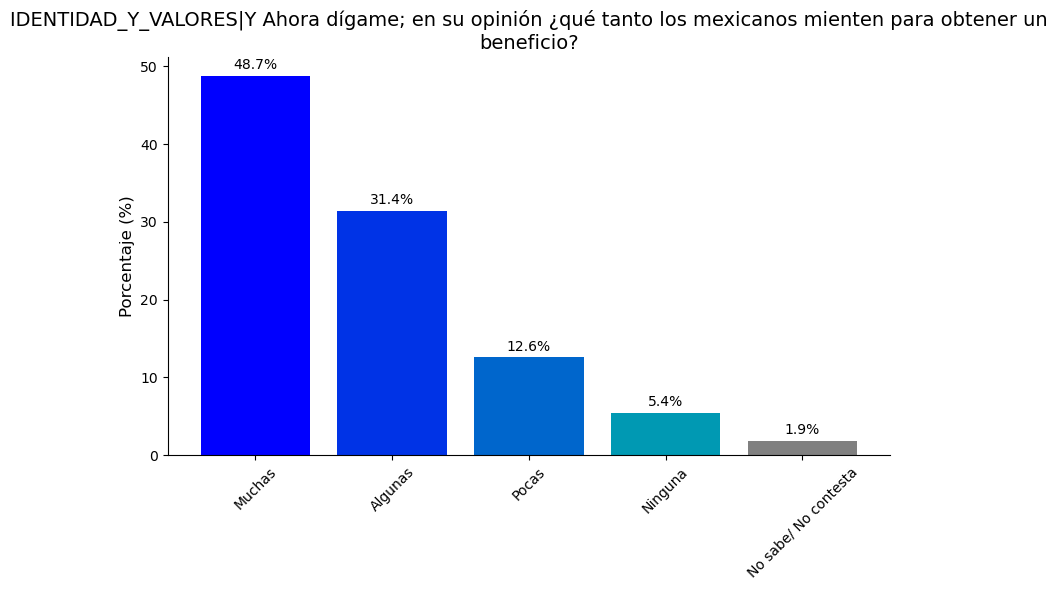

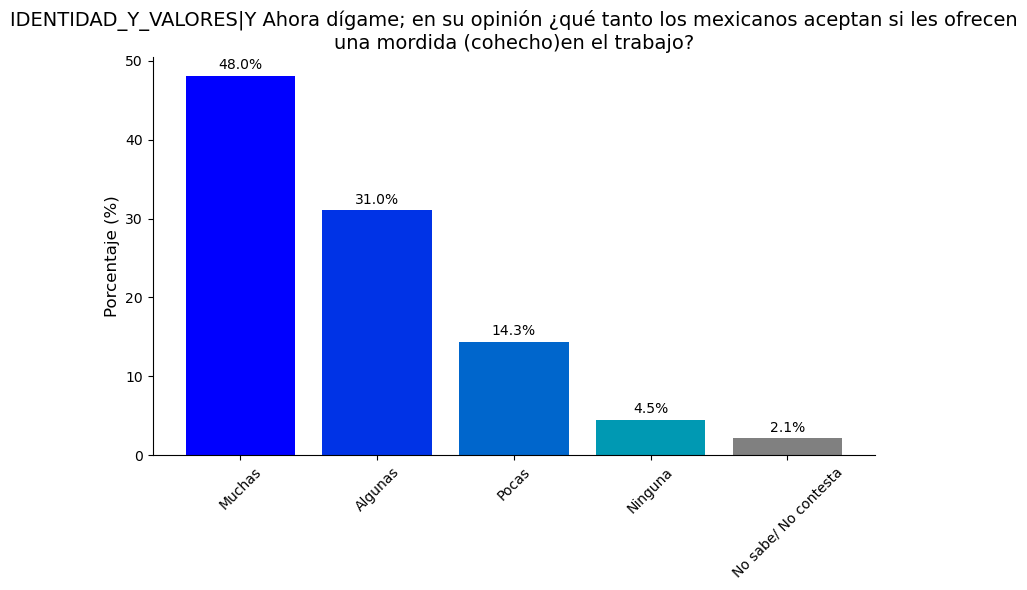

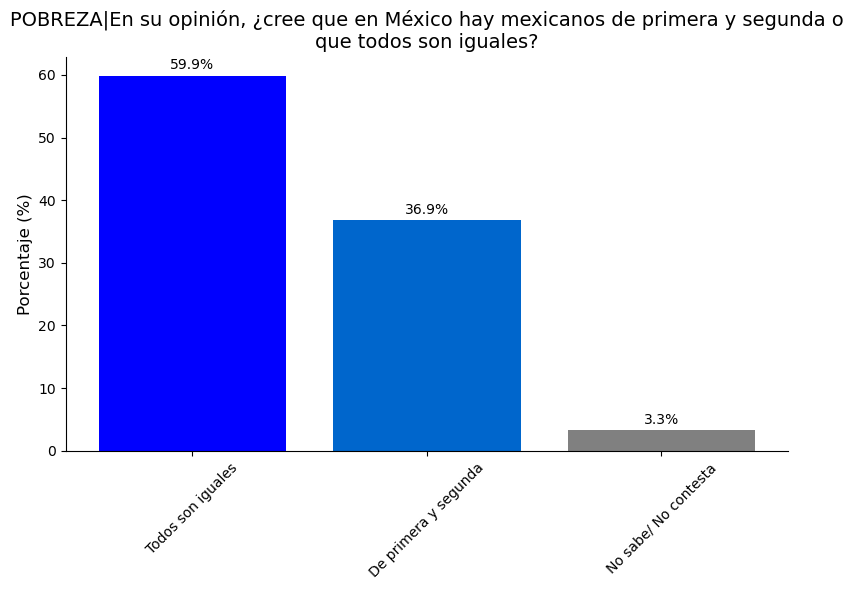

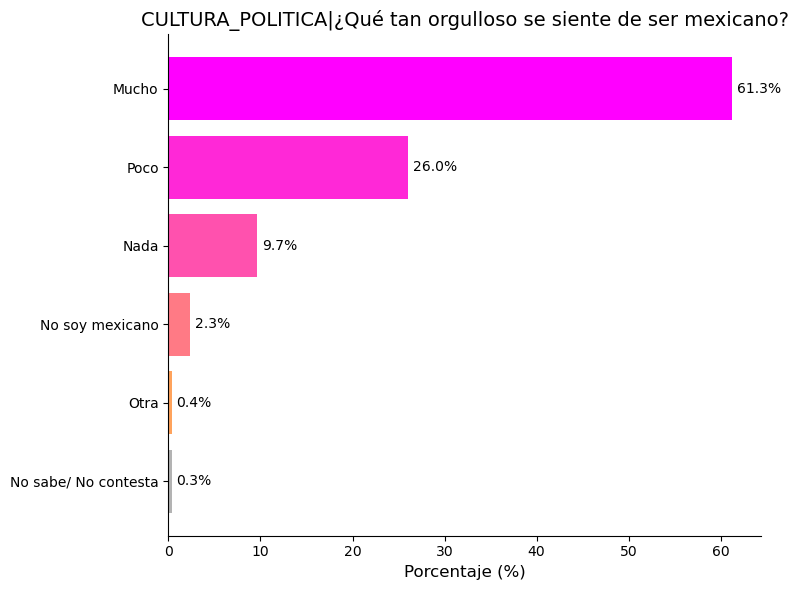

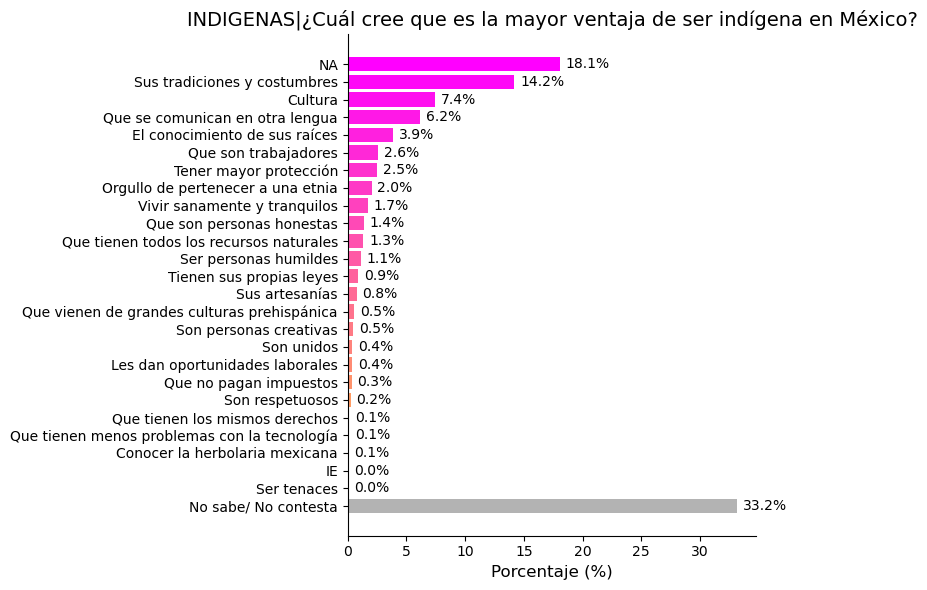

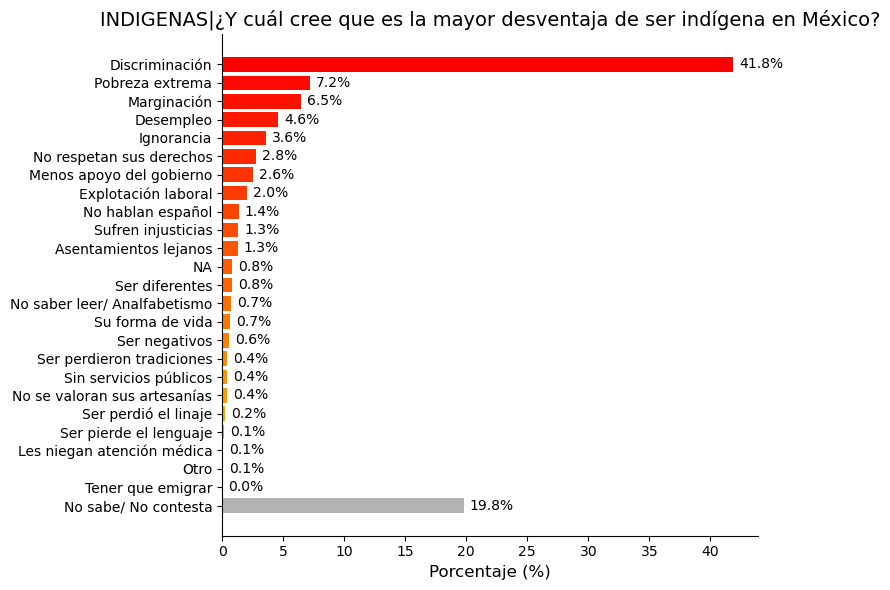

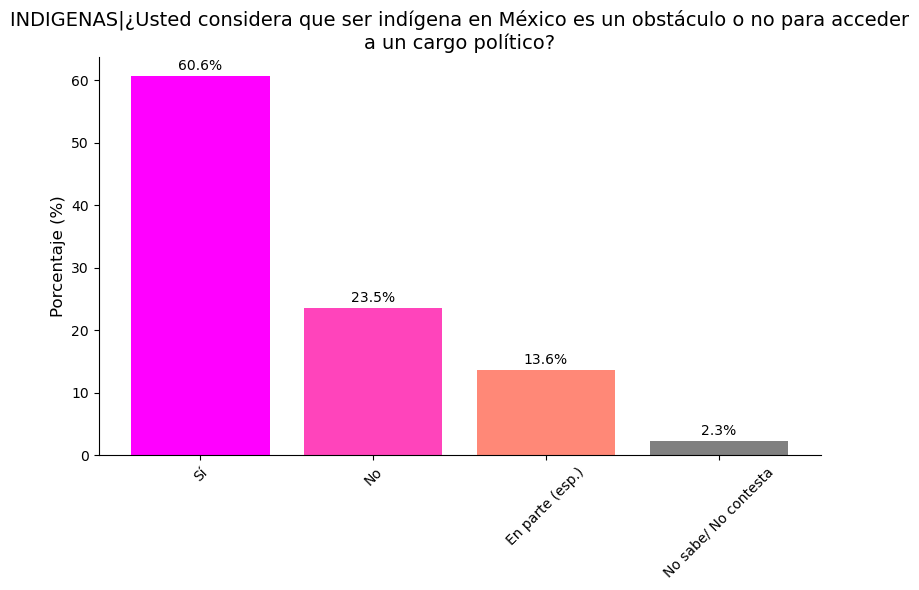

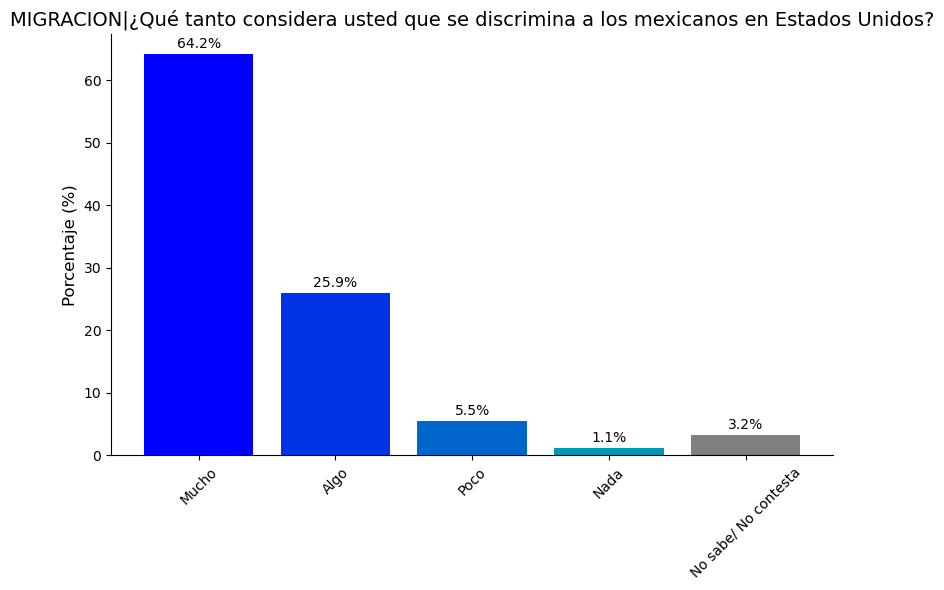

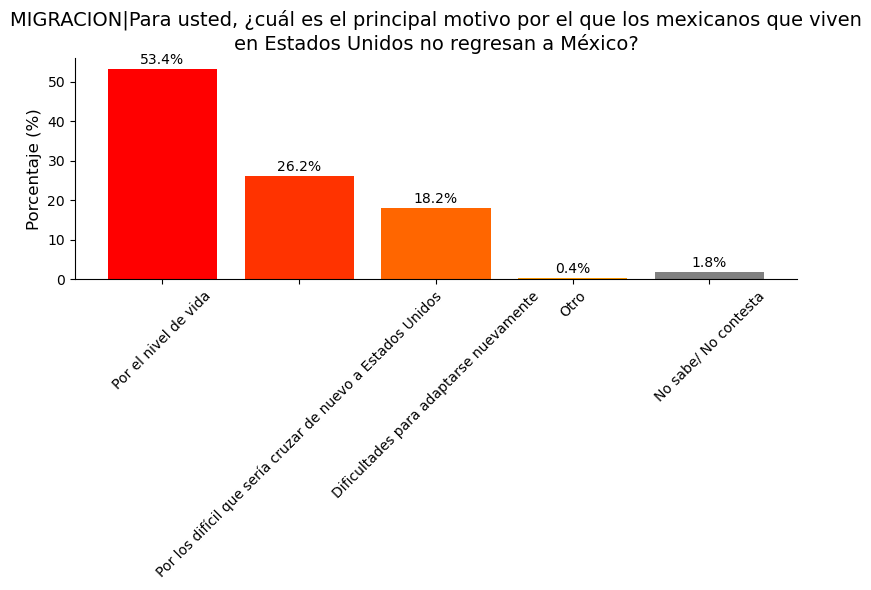

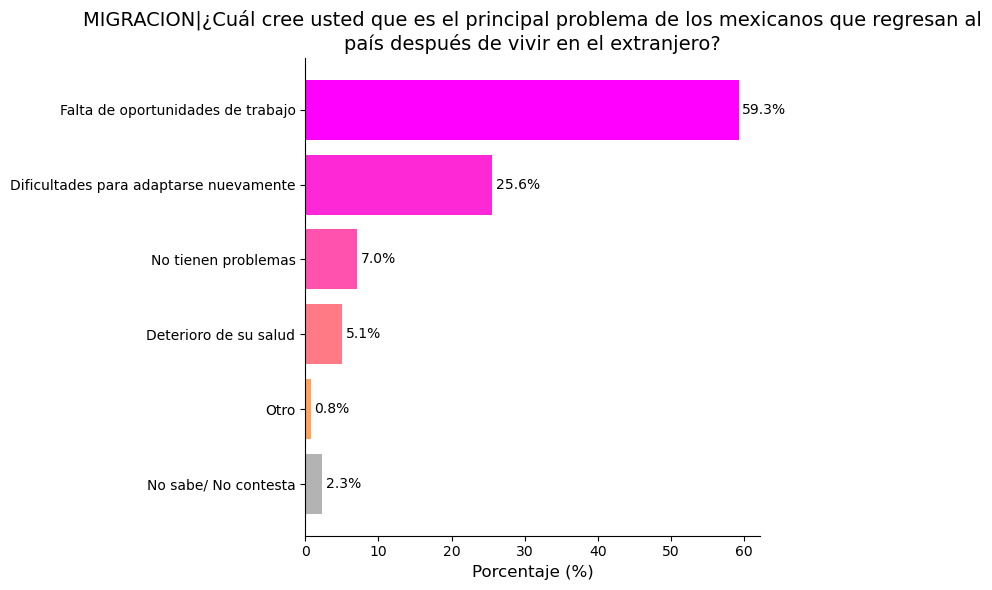

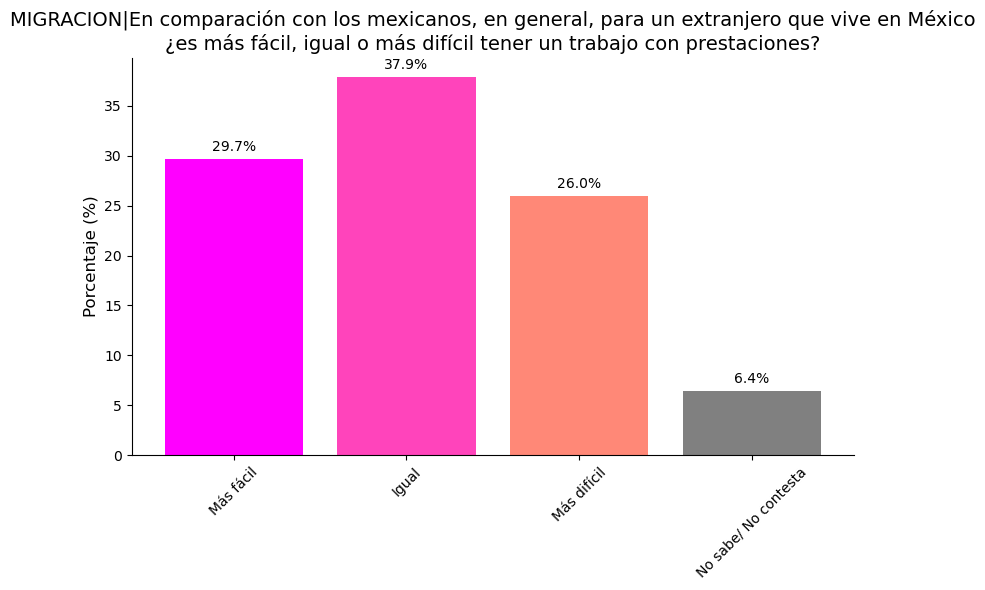

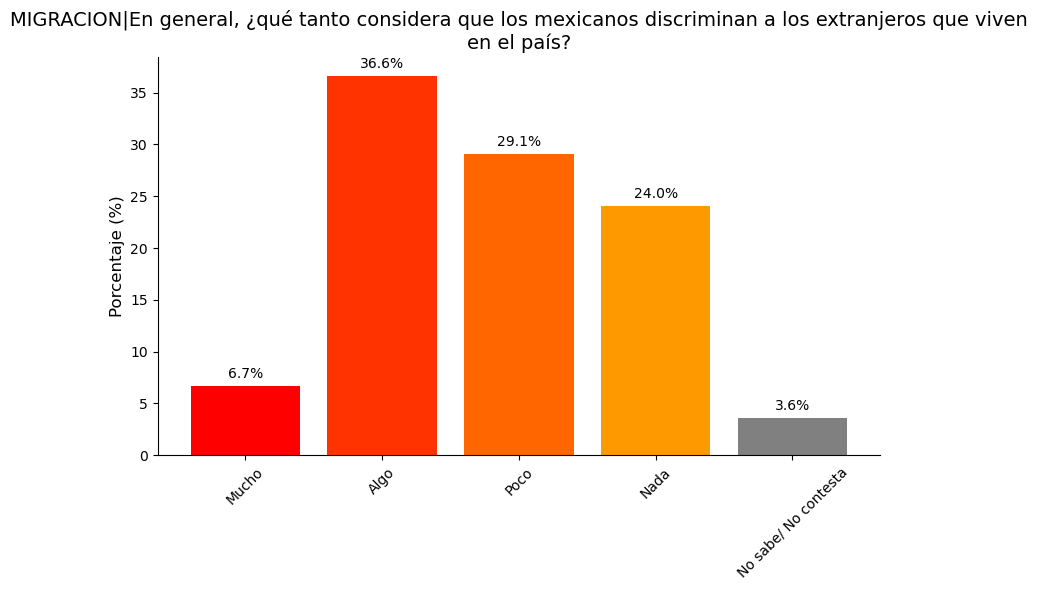

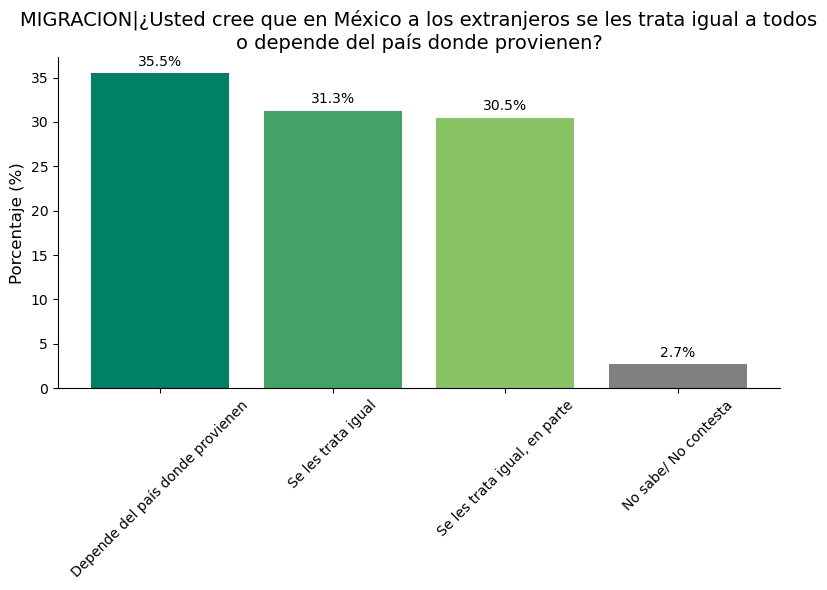

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

def split_text_by_words(text, n=14):
    """
    Splits a string into lines with a maximum of n words per line.

    Args:
        text (str): The input string to split.
        n (int): The maximum number of words per line.

    Returns:
        str: The formatted string with line breaks.
    """
    words = text.split()
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

def create_plot(df, question, figsize=(6, 8)):
    """
    Creates a bar plot (horizontal if rows <= 6, vertical otherwise) of the survey data.

    Args:
        df (pd.DataFrame): DataFrame containing the data to plot.
        question (str): The survey question to use as the plot title.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """
    # Determine plot type based on the number of rows
    if len(df) >= 6:
        # Horizontal bar plot
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create a colormap where 'No sabe/ No contesta' is always gray

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))

        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.7, 0.7, 0.7, 1.0]  # RGBA for gray
        bars = ax.barh(df.index, df['%'], color=colors)

        # Add percentage labels to the bars
        for bar in bars:
            width = bar.get_width()
            label_position = width + 0.5  # Slightly to the right of the bar
            ax.text(label_position, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left', va='center', fontsize=10)
                    # Apply split_text_by_words to tick labels for both axes
        # ax.set_yticklabels([split_text_by_words(label, n=3) for label in df.index], fontsize=10)
        # ax.set_xticklabels([split_text_by_words(str(label), n=3) for label in ax.get_xticks()], fontsize=10)
        # Customize plot
        ax.set_xlabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Invert the y-axis to show the first item at the top
        ax.invert_yaxis()
        plt.tight_layout()

    else:
        # Vertical bar plot
        fig, ax = plt.subplots(figsize=figsize)

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))
        
        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.5, 0.5, 0.5, 1.0]  # RGBA for gray

        bars = ax.bar(df.index, df['%'], color=colors)

        # Add percentage labels above the bars
        for bar in bars:
            height = bar.get_height()
            label_position = height + 0.5
            ax.text(bar.get_x() + bar.get_width()/2, label_position,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10)
        # ax.set_yticklabels([split_text_by_words(label, n=3) for label in df.index], fontsize=10)
        # ax.set_xticklabels([split_text_by_words(str(label), n=3) for label in ax.get_xticks()], fontsize=10)

        # Customize plot
        ax.set_ylabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()

    return fig

# Example usage:
for key, df in tmp_df_dict.items():
    question = tmp_pregs_dict.get(key, 'Unknown Question')
    fig = create_plot(df, question, figsize=(8, 6))
    plt.show()  # Display each plot

In [ ]:
# TODO: crear markdown y pdf con resultados

In [ ]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Create a directory for the plots if it doesn't exist
plots_dir = "plot_images"
os.makedirs(plots_dir, exist_ok=True)

# Get current timestamp for the report
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Title - use your query variable
markdown_doc = f"# {query}\n\n"

# Add timestamp to the document
markdown_doc += f"*Generado en: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*\n\n"

# Summary section - using answer_resumen
markdown_doc += f"## Resumen: \n\n{tmp_res_ans}\n\n"

# Add each analysis and its corresponding plot
for ky in tmp_sum_dict.keys():
    question = tmp_pregs_dict.get(ky, f"Código: {ky}")
    markdown_doc += f"## {question}\n\n"
    
    # Add the answer/analysis
    markdown_doc += f"{tmp_sum_dict[ky]['answer']}\n\n"
    
    # Save the plot as an image
    plot_path = f"{plots_dir}/plot_{ky.replace('|', '_')}.png"
    
    # Create and save the plot
    try:
        fig = create_plot(tmp_df_dict[ky], question, figsize=(8, 6))
        fig.savefig(plot_path, format='png', bbox_inches='tight', dpi=300)
        plt.close(fig)  # Close the plot to free up memory
        
        # Add the plot to the markdown with a caption
        markdown_doc += f"![{question}]({plot_path})\n\n"
        # markdown_doc += f"*Figure: Distribution of responses for '{question}'*\n\n"
    except Exception as e:
        markdown_doc += f"*Error generating plot: {str(e)}*\n\n"

# Display the markdown document
display(Markdown(markdown_doc))

ruta_rep = '/Users/salvadorVMA/Google Drive/01 Proyectos/2025/navegador/reportes'

# Save the markdown to a file
markdown_file = f"report_{timestamp}.md"
with open(ruta_rep + markdown_file, "w", encoding="utf-8") as f:
    f.write(markdown_doc)
print(f"Markdown saved to {markdown_file}")

# Convert to PDF using pypandoc
import pypandoc

output_pdf = f"report_{timestamp}.pdf"
try:
    pypandoc.convert_text(
        markdown_doc,
        to="pdf",
        format="md",
        outputfile=ruta_rep + output_pdf,
        extra_args=[
            "--pdf-engine=xelatex",
            "--variable=geometry:margin=1in",
            "--variable=mainfont:DejaVu Sans",
            "--variable=fontsize:12pt"
        ]
    )
    print(f"PDF report saved to {output_pdf}")
except Exception as e:
    print(f"Error converting to PDF: {str(e)}")
    print("You can try converting the markdown file manually with Pandoc or another tool.")

# ¿qué significa ser mexicano para los mexicanos?

*Generado en: 2025-04-30 14:24:32*

## Resumen: 

Los resultados del estudio revelan que, para la mayoría de los mexicanos, ser mexicano implica un fuerte sentido de identidad y orgullo nacional, pues aproximadamente el 60% de los encuestados expresa sentirse muy orgulloso de su nacionalidad. Este alto porcentaje indica que la pertenencia a la comunidad mexicana es vista como un aspecto fundamental de su identidad personal y social. Sin embargo, la percepción negativa que surge respecto a otros aspectos, como la corrupción y la honestidad, muestra una visión compleja y, en algunos casos, cínica sobre qué significa ser mexicano en términos de valores y comportamiento social.

En cuanto a los valores y comportamientos asociados a la identidad mexicana, una proporción significativa de encuestados considera que los mexicanos aceptan mucho la corrupción en el ámbito laboral, con casi el 50% señalando que es así. Esto indica una tolerancia notable hacia prácticas corruptas, lo que puede reflejar una normalización cultural de ciertos niveles de cohecho que, en la percepción social, están integrados en lo que implica ser mexicano. Igualmente, la percepción de que la mayoría ve a México como una sociedad donde todos los mexicanos son iguales en un 60% también confirma que la igualdad social es un valor asociado, aunque en la práctica persisten vistas sobre desigualdades sociales y de oportunidades.

La percepción sobre los desafíos que enfrentan los mexicanos, particularmente en el contexto indígena y migratorio, también es reveladora. La mayoría considera que ser indígena en México representa una fuente de discriminación, siendo la exclusión y la falta de respeto a sus derechos los aspectos más destacados. Esto refuerza la idea de que ser mexicano también está vinculado a enfrentarse a desigualdades y obstáculos sociales, además de reflejar un reconocimiento de la importancia de la cultura y las tradiciones como parte esencial de la identidad nacional. La percepción de que ser indígena puede ser un obstáculo para acceder a cargos políticos también refleja la existencia de prejuicios y discriminación estructural en la sociedad mexicana.

Dado que la percepción de discriminación en el extranjero y en el trabajo también forma parte de los resultados, parecería importante reforzar la imagen de México a nivel internacional y reducir los prejuicios. La percepción de que los mexicanos enfrentan discriminación significativa en Estados Unidos, y que la migración está motivada principalmente por el nivel de vida, muestra una identidad que busca mejores condiciones sociales. Este aspecto debe ser aprovechado en campañas que destaquen la resiliencia y el carácter trabajo de los mexicanos, promoviendo una visión positiva que contrarreste las percepciones negativas sobre la moralidad y la ética en la sociedad mexicana.

En base a estos resultados, recomiendo diseñar campañas de comunicación y programas culturales que refuercen los aspectos positivos de la identidad mexicana, como su cultura, tradiciones y solidaridad. Es clave también abordar la percepción de corrupción y discriminación, promoviendo valores de integridad y respeto hacia diferentes comunidades. Además, implementar políticas que combatan la corrupción y las desigualdades sociales ayudará a mejorar la imagen de México tanto a nivel interno como internacional, fortaleciendo el sentido de orgullo y pertenencia. La percepción de identidad fuerte y orgullo en la mayoría de los mexicanos proporciona una base sólida para liderar estos esfuerzos de cambio social hacia una visión más positiva y equitativa del ser mexicano.

## IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?

Ser mexicano en términos de honestidad y valores puede estar asociado con percepciones de comportamiento y comportamiento social. La percepción predominante de que muchas personas mienten para obtener beneficios refleja una visión cínica, pero también puede indicar que ser mexicano implica, en la percepción social, enfrentarse a desafíos relacionados con la moralidad y la ética en la búsqueda de beneficios personales.

![IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?](plot_images/plot_p46_4_IDE.png)

## IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo?

Ser mexicano, en opinión de los encuestados, implica una aceptación significativa de la corrupción en el ámbito laboral. Esto refleja una tolerancia considerable hacia la corrupción, sugiriendo que la cultura puede normalizar ciertos niveles de cohecho en la sociedad mexicana.

![IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo?](plot_images/plot_p46_8_IDE.png)

## POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?

Ser mexicano para los mexicanos significa, en la mayoría de los casos, una igualdad social, donde todos son considerados iguales. Sin embargo, una proporción significativa todavía reconoce la existencia de desigualdades, reflejando que la identidad mexicana puede implicar tanto igualdad como división social en diferentes contextos.

![POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?](plot_images/plot_p32_POB.png)

## CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?

Ser mexicano, para la mayoría de los encuestados, significa sentir un gran orgullo por su país. Esto refleja un fuerte sentido de identidad y pertenencia nacional, donde el orgullo es un aspecto central de lo que significa ser mexicano.

![CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?](plot_images/plot_p5_CUL.png)

## INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?

Ser mexicano significa, para los mexicanos, principalmente mantener sus tradiciones, cultura y sus raíces, lo que refleja un sentido profundo de identidad y orgullo cultural. Estas características son interpretadas como los valores fundamentales que definen qué significa ser mexicano, resaltando la importancia de su herencia cultural y comunidad.

![INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?](plot_images/plot_p13_IND.png)

## INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?

Ser mexicano implica, según la percepción de los encuestados, ser parte de un grupo que enfrenta principalmente la discriminación. Esto confirma que la identidad mexicana, en el contexto indígena, está estrechamente vinculada a experiencias de exclusión y desigualdad social y económica.

![INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?](plot_images/plot_p14_IND.png)

## INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para acceder a un cargo político?

Ser mexicano, en este contexto, significa que la mayoría de los mexicanos perciben que ser indígena puede ser un obstáculo para acceder a cargos políticos. Esto refleja una percepción de discriminación o desigualdad racial y social en el país, en la que ser indígena aún puede limitar las oportunidades políticas.

![INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para acceder a un cargo político?](plot_images/plot_p34_5_IND.png)

## MIGRACION|¿Qué tanto considera usted que se discrimina a los mexicanos en Estados Unidos?

Ser mexicano para los mexicanos significa enfrentarse a una percepción fuerte de discriminación en Estados Unidos. La mayoría coincide en que existe una discriminación significativa, lo que puede reflejar una experiencia o percepción común de desigualdad y prejuicio hacia los mexicanos en el contexto migratorio.

![MIGRACION|¿Qué tanto considera usted que se discrimina a los mexicanos en Estados Unidos?](plot_images/plot_p31_MIG.png)

## MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?

Dado que la mayoría de los mexicanos en Estados Unidos permanecen debido al nivel de vida, ser mexicano para ellos implica buscar mejores condiciones sociales y económicas, valorando el bienestar y las oportunidades que perciben en Estados Unidos.

![MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?](plot_images/plot_p37_MIG.png)

## MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?

Ser mexicano, desde esta perspectiva, implica afrontar desafíos relacionados con la integración social y económica, principalmente por la falta de oportunidades laborales. La fuerte preocupación por reinsertarse en el país y superar las dificultades de adaptación refleja que la identidad mexicana está vinculada también con la resiliencia y capacidad de afrontar adversidades relacionadas con la migración y retorno.

![MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?](plot_images/plot_p39_MIG.png)

## MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con prestaciones?

Basándose en estos datos, ser mexicano en México se asocia con una percepción relativamente equilibrada en cuanto a las dificultades para conseguir un empleo con prestaciones, aunque la mayoría cree que no hay diferencia significativa. Esto sugiere que ser mexicano implica un estatus que no necesariamente facilita ni dificulta la obtención de beneficios laborales en comparación con los extranjeros en el país.

![MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con prestaciones?](plot_images/plot_p50_2_MIG.png)

## MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?

Ser mexicano se asocia con una percepción variada del trato hacia los extranjeros, donde la mayoría piensa que existe cierta discriminación. Esto refleja que, para muchos mexicanos, ser parte del país implica vivir en un entorno donde aún persisten actitudes de exclusión hacia los extranjeros.

![MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?](plot_images/plot_p51_MIG.png)

## MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?

Aunque la tabla no aborda directamente qué significa ser mexicano, podemos inferir que la percepción sobre el trato hacia extranjeros refleja el valor que los mexicanos atribuyen a la diversidad y la igualdad. Ser mexicano implica para muchos una identidad que acepta diferentes orígenes, pero que también está condicionada por las experiencias y percepciones de trato en la sociedad.

![MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?](plot_images/plot_p52_MIG.png)



Markdown saved to report_2025-04-30_14-24-32.md
Error converting to PDF: Pandoc died with exitcode "43" during conversion: b'Error producing PDF.\n! Package fontspec Error: The font "DejaVu Sans" cannot be found.\n\nFor immediate help type H <return>.\n ...                                              \n                                                  \nl.20 \\fi\n\n'
You can try converting the markdown file manually with Pandoc or another tool.


In [ ]:
output_pdf = f"report_{timestamp}.pdf"
output_path = os.path.join(ruta_rep, output_pdf)

# Try multiple approaches for PDF generation
try:
    # Attempt 1: Use Helvetica (commonly available on macOS)
    pypandoc.convert_text(
        markdown_doc,  # Just the markdown content
        to="pdf",
        format="md",
        outputfile=output_path,  # Proper path without duplication
        extra_args=[
            "--pdf-engine=xelatex",
            "--variable=geometry:margin=1in",
            "--variable=mainfont:Helvetica",
            "--variable=fontsize:12pt"
        ]
    )
    print(f"PDF report saved to {output_pdf}")
except Exception as e:
    try:
        # Attempt 2: Try with a generic sans font
        pypandoc.convert_text(
            markdown_doc,  # Just the markdown content
            to="pdf",
            format="md",
            outputfile=output_path,  # Proper path without duplication
            extra_args=[
                "--pdf-engine=xelatex",
                "--variable=geometry:margin=1in",
                "--variable=mainfont:Times",  # Times should be available on most systems
                "--variable=fontsize:12pt"
            ]
        )
        print(f"PDF report saved to {output_pdf} (using alternative font)")
    except Exception as e2:
        try:
            # Attempt 3: Use pdflatex instead of xelatex
            pypandoc.convert_text(
                markdown_doc,  # Just the markdown content
                to="pdf",
                format="md",
                outputfile=output_path,  # Proper path without duplication
                extra_args=[
                    "--pdf-engine=pdflatex",
                    "--variable=geometry:margin=1in",
                    "--variable=fontsize:12pt"
                ]
            )
            print(f"PDF report saved to {output_pdf} (using pdflatex)")
        except Exception as e3:
            print(f"Failed to convert to PDF. Error details:")
            print(f"Attempt 1: {str(e)}")
            print(f"Attempt 2: {str(e2)}")
            print(f"Attempt 3: {str(e3)}")
            print(f"Markdown file saved at: {ruta_rep}")
            print("You can try converting the markdown file manually with:")
            print(f"pandoc {ruta_rep}/{markdown_file} -o {output_path} --pdf-engine=pdflatex")

PDF report saved to report_2025-04-30_14-24-32.pdf


### langchain

In [ ]:
import getpass
import os

# una forma alternativa de cargar las variables de entorno:os.environ devuelve un dict con las variables de entorno, 
# y os.getenv devuelve el valor de una variable de entorno.

try:
    # load environment variables from .env file (requires `python-dotenv`)
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

os.environ["LANGSMITH_TRACING"] = "true"
if "LANGSMITH_API_KEY" not in os.environ:
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass(
        prompt="Enter your LangSmith API key (optional): "
    )
if "LANGSMITH_PROJECT" not in os.environ:
    os.environ["LANGSMITH_PROJECT"] = getpass.getpass(
        prompt='Enter your LangSmith Project Name (default = "default"): '
    )
    if not os.environ.get("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = "default"
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass(
        prompt="Enter your OpenAI API key (required if using OpenAI): "
    )


In [34]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4o-mini", model_provider="openai")

In [35]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage("Translate the following from English into Italian"),
    HumanMessage("hi!"),
]

model.invoke(messages)

AIMessage(content='Ciao!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 20, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BSATAtUeb7afMQiF5RwYWXycD8G7O', 'finish_reason': 'stop', 'logprobs': None}, id='run-bd1de60e-3b26-4ab9-a9e4-ec2b83908ec0-0', usage_metadata={'input_tokens': 20, 'output_tokens': 4, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [36]:
from langchain_core.prompts import ChatPromptTemplate

system_template = "Translate the following from English into {language}"

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template), ("user", "{text}")]
)

In [37]:
from langchain_core.prompts import ChatPromptTemplate

template = ChatPromptTemplate([
    ("system", "You are a helpful AI bot. Your name is {name}."),
    ("human", "Hello, how are you doing?"),
    ("ai", "I'm doing well, thanks!"),
    ("human", "{user_input}"),
])

prompt_value = template.invoke(
    {
        "name": "Bob",
        "user_input": "What is your name?"
    }
)

prompt_value
# Output:
# ChatPromptValue(
#    messages=[
#        SystemMessage(content='You are a helpful AI bot. Your name is Bob.'),
#        HumanMessage(content='Hello, how are you doing?'),
#        AIMessage(content="I'm doing well, thanks!"),
#        HumanMessage(content='What is your name?')
#    ]
#)

ChatPromptValue(messages=[SystemMessage(content='You are a helpful AI bot. Your name is Bob.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Hello, how are you doing?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm doing well, thanks!", additional_kwargs={}, response_metadata={}), HumanMessage(content='What is your name?', additional_kwargs={}, response_metadata={})])

In [39]:
prompt = prompt_template.invoke({"language": "Italian", "text": "hi!"})

prompt.to_messages()

[SystemMessage(content='Translate the following from English into Italian', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='hi!', additional_kwargs={}, response_metadata={})]

In [40]:
response = model.invoke(prompt)
print(response.content)

Ciao!


In [41]:
model.invoke([HumanMessage(content="What's my name?")])

AIMessage(content="I'm sorry, but I don't have access to personal information about users unless you've shared it with me during our conversation. If you'd like, you can tell me your name!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 11, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BSBZftPrlVRO5iWmTmWIqje10Fs7u', 'finish_reason': 'stop', 'logprobs': None}, id='run-b8c36b92-4388-45d1-849c-dba4525f1149-0', usage_metadata={'input_tokens': 11, 'output_tokens': 35, 'total_tokens': 46, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [42]:
from langchain_core.messages import AIMessage

model.invoke(
    [
        HumanMessage(content="Hi! I'm Bob"),
        AIMessage(content="Hello Bob! How can I assist you today?"),
        HumanMessage(content="What's my name?"),
    ]
)

AIMessage(content='Your name is Bob! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 33, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BSBaKV2maprlTdyTQqeZDs3Rz0NDw', 'finish_reason': 'stop', 'logprobs': None}, id='run-52323ac4-daad-49a7-86f9-9e0559e70b16-0', usage_metadata={'input_tokens': 33, 'output_tokens': 13, 'total_tokens': 46, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [44]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

# Define a new graph
workflow = StateGraph(state_schema=MessagesState)


# Define the function that calls the model
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


# Define the (single) node in the graph
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# add thread_id to the config to support multiple conversations
config = {"configurable": {"thread_id": "abc123"}}

In [45]:
query = "Hi! I'm Bob."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()  # output contains all messages in state

================================== Ai Message ==================================

Hi Bob! How can I assist you today?


In [46]:
query = "What's my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Bob! How can I help you today?


In [47]:
# different thread_id!
config = {"configurable": {"thread_id": "abc234"}}

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

I don’t know your name unless you tell me. How can I assist you today?


In [48]:
# and retrun to the older thread: 
config = {"configurable": {"thread_id": "abc123"}}

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Bob. What else would you like to talk about?


In [54]:
## crear un template para el prompt
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You talk like a pirate, but in Spanish. Answer all questions to the best of your ability.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [55]:
# define la gráfica nueva, que llama al prompt template y luego al modelo

workflow = StateGraph(state_schema=MessagesState)


def call_model(state: MessagesState):
    prompt = prompt_template.invoke(state)
    response = model.invoke(prompt)
    return {"messages": response}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [56]:
config = {"configurable": {"thread_id": "abc345"}}
query = "Hola, me llamo Pepe."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Ahoy, Pepe! ¡Bienvenido a bordo de este barco pirata! ¿Qué tesoros buscas en estas aguas?


In [57]:
query = "What is my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Arrr, tu nombre es Pepe, amigo! ¿Cómo puedo ayudarte en esta aventura?


In [58]:
# un prompt más complejo
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [60]:
# una gráfica nueva que ahora incluye el lenguaje como variable

from typing import Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated, TypedDict


class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str


workflow = StateGraph(state_schema=State)


def call_model(state: State):
    prompt = prompt_template.invoke(state)
    response = model.invoke(prompt)
    return {"messages": [response]}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [61]:
config = {"configurable": {"thread_id": "abc456"}}
query = "Hi! I'm Bob."
language = "Spanish"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Hola, Bob! ¿Cómo puedo ayudarte hoy?


In [66]:
query = "What is my name?"
language = "Swedish"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Ditt namn är Bob.


In [82]:
# acortar los mensajes a un límite de tokens para no exceder la ventana del modelo

from langchain_core.messages import SystemMessage, trim_messages

trimmer = trim_messages(
    max_tokens=65,
    strategy="last",
    token_counter=model,
    include_system=True,
    allow_partial=False,
    start_on="human",
)

messages = [
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="whats 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

trimmer.invoke(messages)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='whats 2 + 2', additional_kwargs={}, response_metadata={}),
 AIMessage(content='4', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}),
 AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='yes!', additional_kwargs={}, response_metadata={})]

In [83]:
# el trimmer va antes del modelo
workflow = StateGraph(state_schema=State)

def call_model(state: State):
    trimmed_messages = trimmer.invoke(state["messages"])
    prompt = prompt_template.invoke(
        {"messages": trimmed_messages, "language": state["language"]}
    )
    response = model.invoke(prompt)
    return {"messages": [response]}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [80]:
# el modelo olvidó el nombre porque ya pasó el límite del trimmer
config = {"configurable": {"thread_id": "abc567"}}
query = "What is my name?"
language = "French"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Je ne connais pas votre nom. Comment vous appelez-vous ?


In [84]:
config = {"configurable": {"thread_id": "abc678"}}
query = "What math problem did I ask?"
language = "English"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

It seems you haven't asked a math problem yet. If you have one in mind, feel free to share it, and I'll be happy to help!


In [87]:
### Agentes

# Import relevant functionality
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = ChatAnthropic(model_name="claude-3-sonnet-20240229")
# search = TavilySearchResults(max_results=2)
# tools = [search]
# agent_executor = create_react_agent(model, tools, checkpointer=memory)

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(max_results=2)
search_results = search.invoke("what is the weather in SF")
print(search_results)
# If we want, we can create other tools.
# Once we have all the tools we want, we can put them in a list that we will reference later.
tools = [search]

# TODO: resultado inesperado...

[{'url': 'https://www.weatherapi.com/', 'content': "{'error': {'code': 1006, 'message': 'No matching location found.'}}"}, {'url': 'https://www.journal-news.net/journal-news/weather-drawing-for-may-1-2025/image_81f3d1f3-5b76-5f89-a461-39cc0b4f45da.html', 'content': 'Get our expert short-term forecast, summary of the weather details and news of any severe weather. Delivered every morning. High School Sports.'}]


### sigue debajo

In [28]:
# crea un ciente de chromadb - y fija document_mode a True

# import chromadb

# DB_NAME = "googlecardb"

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# chroma_client = chromadb.Client()
# db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

# db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

In [29]:
# db.count(), db.peek()

In [30]:
# results = db.get()

# results

# print("IDs:", results["ids"])
# print("Documents:", results["documents"])
# print("Embeddings:", results["embeddings"])
# print("Metadatas:", results["metadatas"])

# # ChromaDB does not store embeddings by default for efficiency reasons.
# # To retrieve embeddings, you need to query the database instead of using `db.get()`.

# query_results = db.query(query_texts=[""], n_results=db.count())
# print("Embeddings:", query_results["embeddings"])

In [31]:
# # Switch to query mode when generating embeddings.
# embed_fn.document_mode = False

# # Search the Chroma DB using the specified query.
# query = "How do you use the touchscreen to play music?"

# result = db.query(query_texts=[query], n_results=1)
# [all_passages] = result["documents"]

# Markdown(all_passages[0])

In [32]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [33]:
# answer = client.models.generate_content(
#     model="gemini-2.0-flash",
#     contents=prompt)

# Markdown(answer.text)

#### similarity scores

In [34]:
# calcular la similitud entre documentos

texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]


response = client.models.embed_content(
    model='models/text-embedding-004',
    contents=texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

In [35]:
# el modelo de embeddings como diccionario y los embeddings directos    
response.model_dump(), response.embeddings

({'embeddings': [{'values': [-0.0922682,
     0.012113783,
     -0.0063794684,
     0.0369048,
     0.02203019,
     0.048805293,
     0.0133289965,
     0.021541007,
     0.02705553,
     -0.0043925485,
     -0.011962657,
     0.069833845,
     0.010891116,
     0.06149802,
     0.049922608,
     0.022119658,
     0.0178632,
     0.050096616,
     0.0029887455,
     -0.008278692,
     0.005999019,
     -0.0040636063,
     0.015202278,
     -0.021813663,
     -0.02274539,
     -0.032121718,
     -0.00033075613,
     -0.022031343,
     0.028694874,
     -0.04976425,
     0.025347114,
     0.07245508,
     0.003248612,
     -0.002201165,
     0.059787363,
     -0.0057624904,
     -0.02634191,
     -0.003782781,
     0.048398733,
     0.0066004205,
     -0.05704449,
     -0.022870814,
     -0.058460187,
     0.013212032,
     0.01834201,
     -0.076267265,
     -0.02015255,
     0.014425502,
     0.0024263572,
     -0.011807308,
     0.056245767,
     -0.0031448188,
     0.0013501083,
   

In [36]:
# la longitud de los embeddings es fija
len(response.embeddings[0].values)

768

In [37]:
# truncar datos para visualización

def truncate(t: str, limit: int = 50) -> str:
  """Truncate labels to fit on the chart."""
  if len(t) > limit:
    return t[:limit-3] + '...'
  else:
    return t

truncated_texts = [truncate(t) for t in texts]

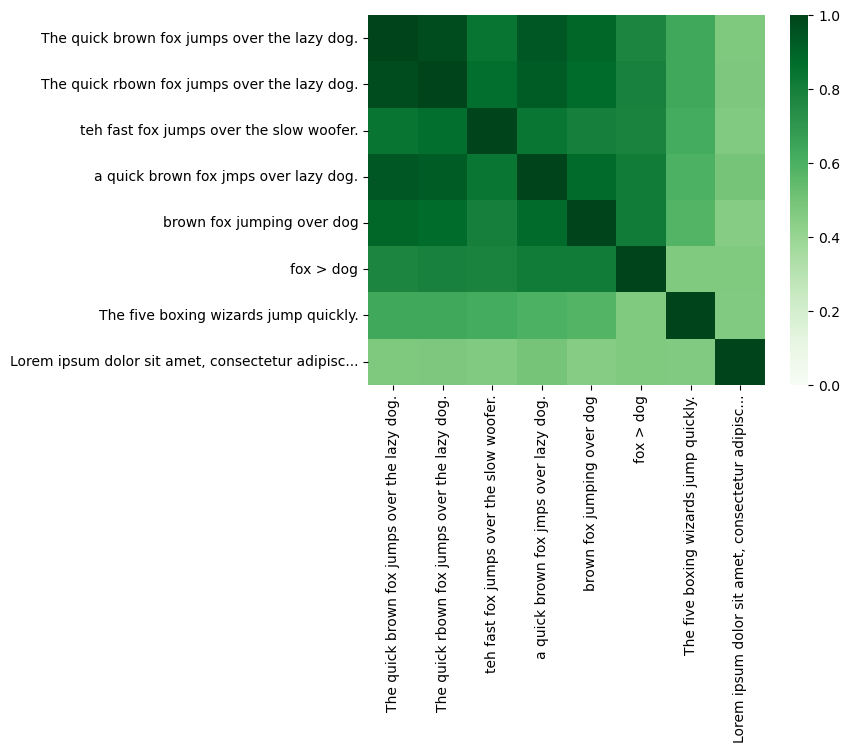

In [38]:
# la similaridad se calcula como el producto punto (inner product) entre los vectores de embedding

import pandas as pd
import seaborn as sns


# Set up the embeddings in a dataframe.
df = pd.DataFrame([e.values for e in response.embeddings], index=truncated_texts)

# la matriz de similardad: 
# Perform the similarity calculation
sim = df @ df.T
# Draw!
sns.heatmap(sim, vmin=0, vmax=1, cmap="Greens");

In [39]:
# sim is a similarity matrix calculated as the dot product of embedding vectors.
# Each entry in sim represents the similarity score between two text embeddings.
sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False)

The quick brown fox jumps over the lazy dog.          0.999999
The quick rbown fox jumps over the lazy dog.          0.975623
a quick brown fox jmps over lazy dog.                 0.939730
brown fox jumping over dog                            0.894507
teh fast fox jumps over the slow woofer.              0.842152
fox > dog                                             0.776455
The five boxing wizards jump quickly.                 0.635346
Lorem ipsum dolor sit amet, consectetur adipisc...    0.472174
Name: The quick brown fox jumps over the lazy dog., dtype: float64

#### clasificación de embeddings con Keras

In [40]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")
newsgroups_test = fetch_20newsgroups(subset="test")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [41]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [42]:
# # preprocesamiento como un mensaje anónimo

# import email
# import re

# import pandas as pd


# def preprocess_newsgroup_row(data):
#     # Extract only the subject and body
#     msg = email.message_from_string(data)
#     text = f"{msg['Subject']}\n\n{msg.get_payload()}"
#     # Strip any remaining email addresses
#     text = re.sub(r"[\w\.-]+@[\w\.-]+", "", text)
#     # Truncate each entry to 5,000 characters
#     text = text[:5000]

#     return text


# def preprocess_newsgroup_data(newsgroup_dataset):
#     # Put data points into dataframe
#     df = pd.DataFrame(
#         {"Text": newsgroup_dataset.data, "Label": newsgroup_dataset.target}
#     )
#     # Clean up the text
#     df["Text"] = df["Text"].apply(preprocess_newsgroup_row)
#     # Match label to target name index
#     df["Class Name"] = df["Label"].map(lambda l: newsgroup_dataset.target_names[l])

#     return df

In [43]:
# # Apply preprocessing function to training and test datasets
# df_train = preprocess_newsgroup_data(newsgroups_train)
# df_test = preprocess_newsgroup_data(newsgroups_test)

# df_train.head()

,Text,Label,Class Name
0,WHAT car is this!?\n\n I was wondering if anyo...,7,rec.autos
1,SI Clock Poll - Final Call\n\nA fair number of...,4,comp.sys.mac.hardware
2,"PB questions...\n\nwell folks, my mac plus fin...",4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\n\nRobert J.C. Kyanko () wr...,1,comp.graphics
4,Re: Shuttle Launch Question\n\nFrom article <>...,14,sci.space


In [44]:
# # muestra de datos y selección de mensajes de ciencia
# def sample_data(df, num_samples, classes_to_keep):
#     # Sample rows, selecting num_samples of each Label.
#     df = (
#         df.groupby("Label")[df.columns]
#         .apply(lambda x: x.sample(num_samples))
#         .reset_index(drop=True)
#     )

#     df = df[df["Class Name"].str.contains(classes_to_keep)]

#     # We have fewer categories now, so re-calibrate the label encoding.
#     df["Class Name"] = df["Class Name"].astype("category")
#     df["Encoded Label"] = df["Class Name"].cat.codes

#     return df

In [45]:
# TRAIN_NUM_SAMPLES = 100
# TEST_NUM_SAMPLES = 25
# # Class name should contain 'sci' to keep science categories.
# # Try different labels from the data - see newsgroups_train.target_names
# CLASSES_TO_KEEP = "sci"

# df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
# df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)

In [46]:
# df_train.value_counts("Class Name")

Class Name
sci.crypt          100
sci.electronics    100
sci.med            100
sci.space          100
Name: count, dtype: int64

#### clasificación

In [47]:
## el modelo de embeddings se puede usar para varias tareas

# Task types
# The text-embedding-004 model supports a task type parameter that generates embeddings tailored for the specific task.

# Task Type	Description
# RETRIEVAL_QUERY	Specifies the given text is a query in a search/retrieval setting.
# RETRIEVAL_DOCUMENT	Specifies the given text is a document in a search/retrieval setting.
# SEMANTIC_SIMILARITY	Specifies the given text will be used for Semantic Textual Similarity (STS).
# CLASSIFICATION	Specifies that the embeddings will be used for classification.
# CLUSTERING	Specifies that the embeddings will be used for clustering.
# FACT_VERIFICATION	Specifies that the given text will be used for fact verification.
# For this example you will be performing classification.

In [48]:
# # clasificación de texto

# from google.api_core import retry
# import tqdm
# from tqdm.rich import tqdm as tqdmr
# import warnings

# # Add tqdm to Pandas...
# tqdmr.pandas()

# # ...But suppress the experimental warning.
# warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)

# # Define a helper to retry when per-minute quota is reached.
# is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

# @retry.Retry(predicate=is_retriable, timeout=300.0)
# def embed_fn(text: str) -> list[float]:
#     # You will be performing classification, so set task_type accordingly.
#     response = client.models.embed_content(
#         model="models/text-embedding-004",
#         contents=text,
#         config=types.EmbedContentConfig(
#             task_type="classification",
#         ),
#     )

#     return response.embeddings[0].values


# def create_embeddings(df):
#     df["Embeddings"] = df["Text"].progress_apply(embed_fn)
#     return df

In [49]:
#toma aprox 4 -8 mins

# df_train = create_embeddings(df_train)
# df_test = create_embeddings(df_test)

In [50]:
# df_train.head()

In [51]:
# # construcción de un modelo de clasificación con keras

# import keras
# from keras import layers


# def build_classification_model(input_size: int, num_classes: int) -> keras.Model:
#     return keras.Sequential(
#         [
#             layers.Input([input_size], name="embedding_inputs"),
#             layers.Dense(input_size, activation="relu", name="hidden"),
#             layers.Dense(num_classes, activation="softmax", name="output_probs"),
#         ]
#     )

In [52]:
# # Derive the embedding size from observing the data. The embedding size can also be specified
# # with the `output_dimensionality` parameter to `embed_content` if you need to reduce it.
# embedding_size = len(df_train["Embeddings"].iloc[0])

# classifier = build_classification_model(
#     embedding_size, len(df_train["Class Name"].unique())
# )
# classifier.summary()

# classifier.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     metrics=["accuracy"],
# )

In [53]:
# # modelo de clasificación
# # The model is compiled and ready to train.

# import numpy as np


# NUM_EPOCHS = 20
# BATCH_SIZE = 32

# # Split the x and y components of the train and validation subsets.
# y_train = df_train["Encoded Label"]
# x_train = np.stack(df_train["Embeddings"])
# y_val = df_test["Encoded Label"]
# x_val = np.stack(df_test["Embeddings"])

# # Specify that it's OK to stop early if accuracy stabilises.
# early_stop = keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

# # Train the model for the desired number of epochs.
# history = classifier.fit(
#     x=x_train,
#     y=y_train,
#     validation_data=(x_val, y_val),
#     callbacks=[early_stop],
#     batch_size=BATCH_SIZE,
#     epochs=NUM_EPOCHS,
# )

In [54]:
# evaluación del modelo

# classifier.evaluate(x=x_val, y=y_val, return_dict=True)

In [55]:
# def make_prediction(text: str) -> list[float]:
#     """Infer categories from the provided text."""
#     # Remember that the model takes embeddings as input, so calculate them first.
#     embedded = embed_fn(new_text)

#     # And recall that the input must be batched, so here they are wrapped as a
#     # list to provide a batch of 1.
#     inp = np.array([embedded])

#     # And un-batched here.
#     [result] = classifier.predict(inp)
#     return result

In [56]:
# # This example avoids any space-specific terminology to see if the model avoids
# # biases towards specific jargon.
# new_text = """
# First-timer looking to get out of here.

# Hi, I'm writing about my interest in travelling to the outer limits!

# What kind of craft can I buy? What is easiest to access from this 3rd rock?

# Let me know how to do that please.
# """

# result = make_prediction(new_text)

# for idx, category in enumerate(df_test["Class Name"].cat.categories):
#     print(f"{category}: {result[idx] * 100:0.2f}%")